#  analysing color frequencies of image

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
import os
import traceback

In [2]:
# Load the image
file_path = "/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group/DM035_F_L.png" 
img = cv2.imread(file_path)
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

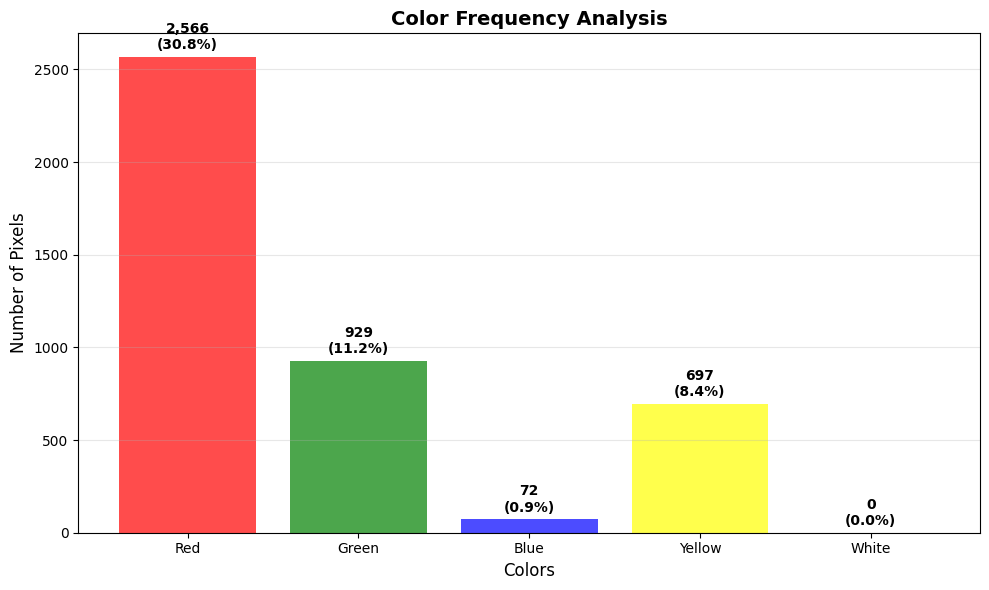

Color Counts: {'Red': np.int64(2566), 'Green': np.int64(929), 'Blue': np.int64(72), 'Yellow': np.int64(697), 'White': np.int64(0)}
Color Percentages: {'Red': np.float64(30.841346153846157), 'Green': np.float64(11.165865384615385), 'Blue': np.float64(0.8653846153846154), 'Yellow': np.float64(8.377403846153845), 'White': np.float64(0.0)}


In [3]:
# Define color ranges in HSV (H: 0-180, S: 0-255, V: 0-255)
color_ranges = {
    'Red': [
        (np.array([0, 120, 70]), np.array([10, 255, 255])),
        (np.array([170, 120, 70]), np.array([180, 255, 255]))
    ],
    'Green': [(np.array([35, 50, 50]), np.array([85, 255, 255]))],
    'Blue': [(np.array([100, 150, 0]), np.array([140, 255, 255]))],
    'Yellow': [(np.array([20, 100, 100]), np.array([30, 255, 255]))],
    'White': [(np.array([0, 0, 200]), np.array([180, 30, 255]))]
}

color_counts = {}
total_pixels = img.shape[0] * img.shape[1]

# Calculate pixel counts for each color
for color_name, ranges in color_ranges.items():
    mask = np.zeros(hsv.shape[:2], dtype=np.uint8)
    for lower, upper in ranges:
        mask = cv2.bitwise_or(mask, cv2.inRange(hsv, lower, upper))
    color_counts[color_name] = np.sum(mask > 0)

# Calculate percentages
color_percentages = {color: (count / total_pixels) * 100 for color, count in color_counts.items()}

# Create the bar graph
colors = list(color_counts.keys())
counts = list(color_counts.values())
percentages = list(color_percentages.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(colors, counts, color=['red', 'green', 'blue', 'yellow', 'white'], alpha=0.7)

# Add value labels on bars
for bar, count, percentage in zip(bars, counts, percentages):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(counts)*0.01,
             f'{count:,}\n({percentage:.1f}%)', ha='center', va='bottom', fontweight='bold')

plt.title('Color Frequency Analysis', fontsize=14, fontweight='bold')
plt.xlabel('Colors', fontsize=12)
plt.ylabel('Number of Pixels', fontsize=12)
plt.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig("color_frequency_bar_chart.png")
plt.show()

print("Color Counts:", color_counts)
print("Color Percentages:", color_percentages)

# By K-Means Color Segmentation 


 K-MEANS CLUSTER CENTERS
Cluster 0: RGB(np.uint8(150), np.uint8(34), np.uint8(14))
Cluster 1: RGB(np.uint8(227), np.uint8(118), np.uint8(116))
Cluster 2: RGB(np.uint8(170), np.uint8(167), np.uint8(10))
Cluster 3: RGB(np.uint8(12), np.uint8(162), np.uint8(159))
Cluster 4: RGB(np.uint8(2), np.uint8(11), np.uint8(2))


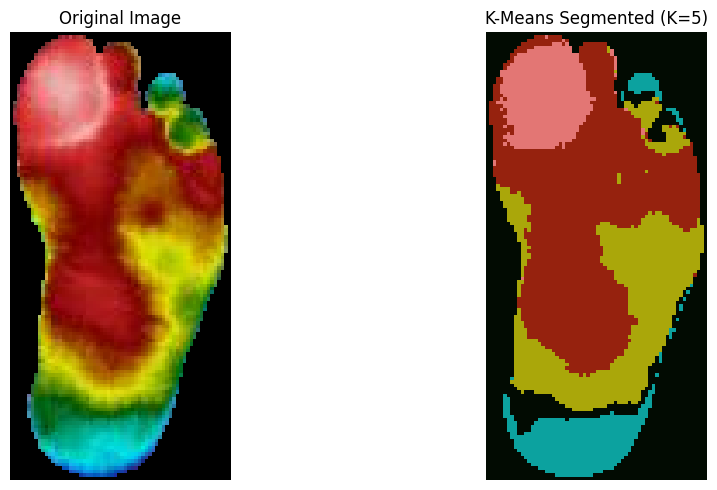

IDENTIFYING RED CLUSTER
 Cluster Index 0 selected as Red Hotspot (RGB: (np.uint8(150), np.uint8(34), np.uint8(14)), Score: 3.06)


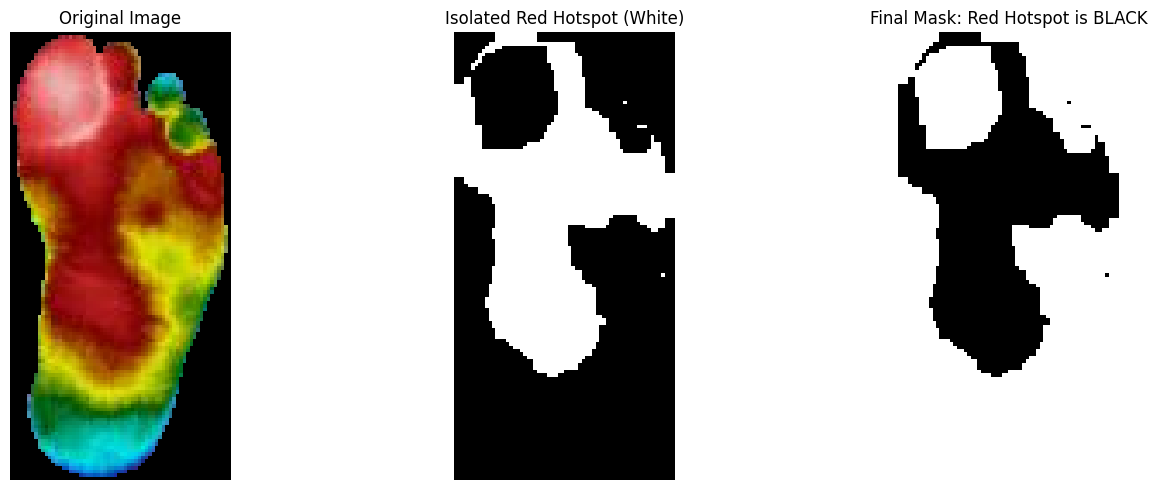


Final desired mask created. Red area is marked as Black (0).


In [4]:
def step1_kmeans_color_clustering(image_path, K=5):
    
    img = cv2.imread(image_path)
    if img is None:
        print(f"Could not load image: {image_path}")
        return None, None, None, None, None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    pixel_data = img_rgb.reshape((-1, 3)).astype(np.float32)
    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 100, 0.2)
    
    # K-Means clustering 
    ret, labels, centers = cv2.kmeans(pixel_data, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    
    centers = np.uint8(centers)
    labels = labels.flatten()
    
    print(" K-MEANS CLUSTER CENTERS")
   
    for i, center in enumerate(centers):
        print(f"Cluster {i}: RGB{tuple(center)}")

    # Visualization
    segmented_data = centers[labels]
    segmented_img = segmented_data.reshape(img_rgb.shape)
    
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(segmented_img)
    plt.title(f'K-Means Segmented (K={K})')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return labels, img_rgb.shape, centers, img_rgb

def step2_isolate_red_mask(labels, img_shape, original_rgb_img, K_centers):
  
    print("IDENTIFYING RED CLUSTER")

    best_index = -1
    max_redness_score = -np.inf

    #the cluster center (R, G, B) that maximizes R / (G + B + 1)
    for i, (R, G, B) in enumerate(K_centers):
        if R > 100:
            # Redness score: R / (G + B + 1)
            redness_score = R / (G + B + 1)
            
            if redness_score > max_redness_score:
                max_redness_score = redness_score
                best_index = i
    
    if best_index == -1:
        print(" Could not reliably find a 'Red' cluster based on heuristic. Defaulting to cluster 0.")
        manual_red_index = 0
    else:
        manual_red_index = best_index

    print(f" Cluster Index {manual_red_index} selected as Red Hotspot (RGB: {tuple(K_centers[manual_red_index])}, Score: {max_redness_score:.2f})")
    
    # 1. Create the binary mask
    red_mask = (labels == manual_red_index).reshape(img_shape[:2]).astype(np.uint8) * 255
    
    # 2. Morphological Cleaning
    kernel = np.ones((5, 5), np.uint8)
    red_mask_clean = cv2.morphologyEx(red_mask, cv2.MORPH_CLOSE, kernel)
    
    # 3. Final Inversion
    final_inverted_mask = cv2.bitwise_not(red_mask_clean)
    
    # Final Visualization
    plt.figure(figsize=(15, 5))
    
    plt.subplot(1, 3, 1)
    plt.imshow(original_rgb_img)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(red_mask_clean, cmap='gray')
    plt.title('Isolated Red Hotspot (White)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(final_inverted_mask, cmap='gray')
    plt.title('Final Mask: Red Hotspot is BLACK')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
    
    return final_inverted_mask


if __name__ == "__main__":    
    # Cluster the image (K=5)
    labels, img_shape, centers, img_rgb = step1_kmeans_color_clustering(file_path, K=5)
    
    if labels is not None:
        #  identify the correct cluster index and generate the mask
        final_mask = step2_isolate_red_mask(labels, img_shape, img_rgb, centers)
        
        if final_mask is not None:
            print("\nFinal desired mask created. Red area is marked as Black (0).")

# Isolating Red colour using HSV ranges

 Initial Red Pixels found: 2,566


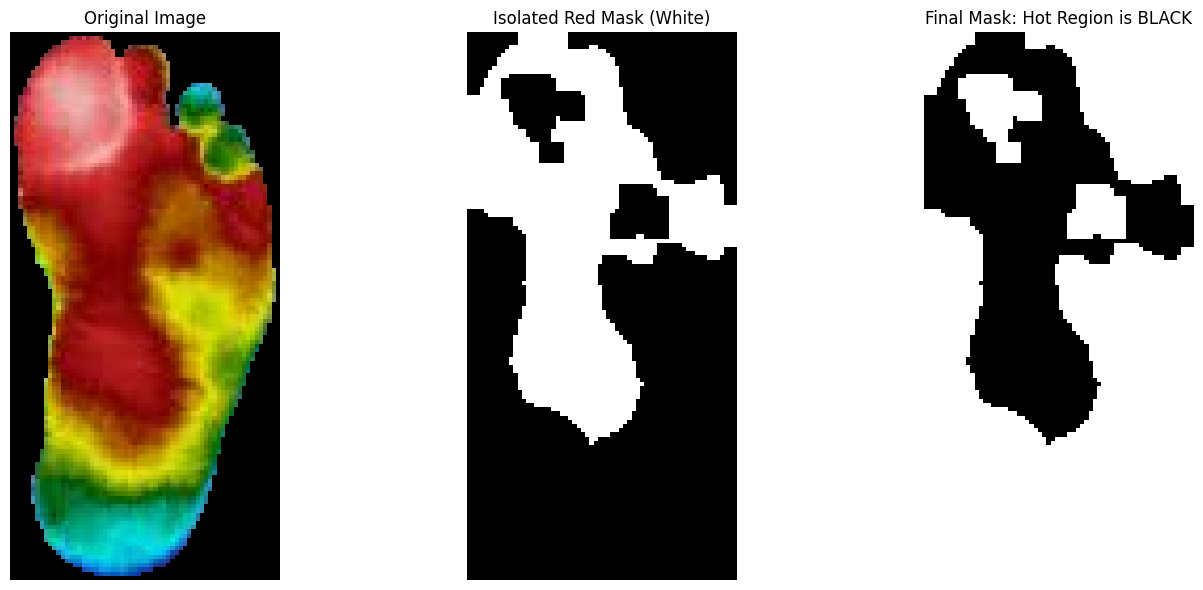

Final Mask successfully generated. The hottest visible region is marked as Black (0).


In [5]:

def generate_and_invert_adaptive_mask(image_path, target_color='Red'):

    if img is None:
        print(f" Error: Could not load image from path: {image_path}")
        return None
        
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # 2. Define Color Ranges)
    color_ranges = {
        'Red': [
            # Red HUE lower range
            (np.array([0, 120, 70]), np.array([10, 255, 255])),
            # Red HUE upper range
            (np.array([170, 120, 70]), np.array([180, 255, 255]))
        ]
    } 

    # 3. Initial Mask Generation
    mask_name = target_color
    
    #  try to generate the mask for the primary target color (Red)
    mask_initial = np.zeros(hsv.shape[:2], dtype=np.uint8)
    
    #  Ensure the key is in color_ranges before accessing
    if mask_name not in color_ranges:
        print(f" Error: Target color '{mask_name}' not defined in color_ranges.")
        return None

    for lower, upper in color_ranges[mask_name]:
        mask_initial = cv2.bitwise_or(mask_initial, cv2.inRange(hsv, lower, upper))
    
    initial_pixels_found = np.sum(mask_initial > 0)
    
    #  switch to Yellow
    if target_color == 'Red' and initial_pixels_found == 0: # 🚨 FIX: Use 'Red' here
        print("Red pixels not found. Switching target to Yellow (the hottest visible region).")
        mask_name = 'Yellow'
        
        # Re-generate mask for Yellow
        mask_initial = np.zeros(hsv.shape[:2], dtype=np.uint8)
        # Check if Yellow is defined before proceeding
        if 'Yellow' in color_ranges:
            for lower, upper in color_ranges[mask_name]:
                mask_initial = cv2.bitwise_or(mask_initial, cv2.inRange(hsv, lower, upper))
            initial_pixels_found = np.sum(mask_initial > 0)
        else:
            print(" Error: Yellow range is missing from color_ranges.")
            initial_pixels_found = 0

    print(f" Initial {mask_name} Pixels found: {initial_pixels_found:,}")
    
    if initial_pixels_found == 0:
        print(" Cannot segment: No hot pixels found in Red or Yellow range.")
        return np.zeros(hsv.shape[:2], dtype=np.uint8)

    # 4. Mask Refinement (Morphological Cleaning)
    kernel = np.ones((5, 5), np.uint8)
    mask_clean = cv2.morphologyEx(mask_initial, cv2.MORPH_CLOSE, kernel)
    
    # 5. Final Inversion (Target Area = Black, Others = White)
    final_inverted_mask1 = cv2.bitwise_not(mask_clean)
    
    # 6. Visualization
    plt.figure(figsize=(15, 6))
    
    plt.subplot(1, 3, 1)
    plt.imshow(img_rgb)
    plt.title('Original Image')
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(mask_clean, cmap='gray')
    plt.title(f'Isolated {mask_name} Mask (White)')
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(final_inverted_mask1, cmap='gray')
    plt.title('Final Mask: Hot Region is BLACK')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

    return final_inverted_mask1

if __name__ == "__main__":

    # The function will first look for Red. 
    final_mask = generate_and_invert_adaptive_mask(file_path, target_color='Red')
    
    if final_mask is not None:
        print("Final Mask successfully generated. The hottest visible region is marked as Black (0).")

# Analysing and extracting all required values from image

Analyzing image: DM035_F_L.png


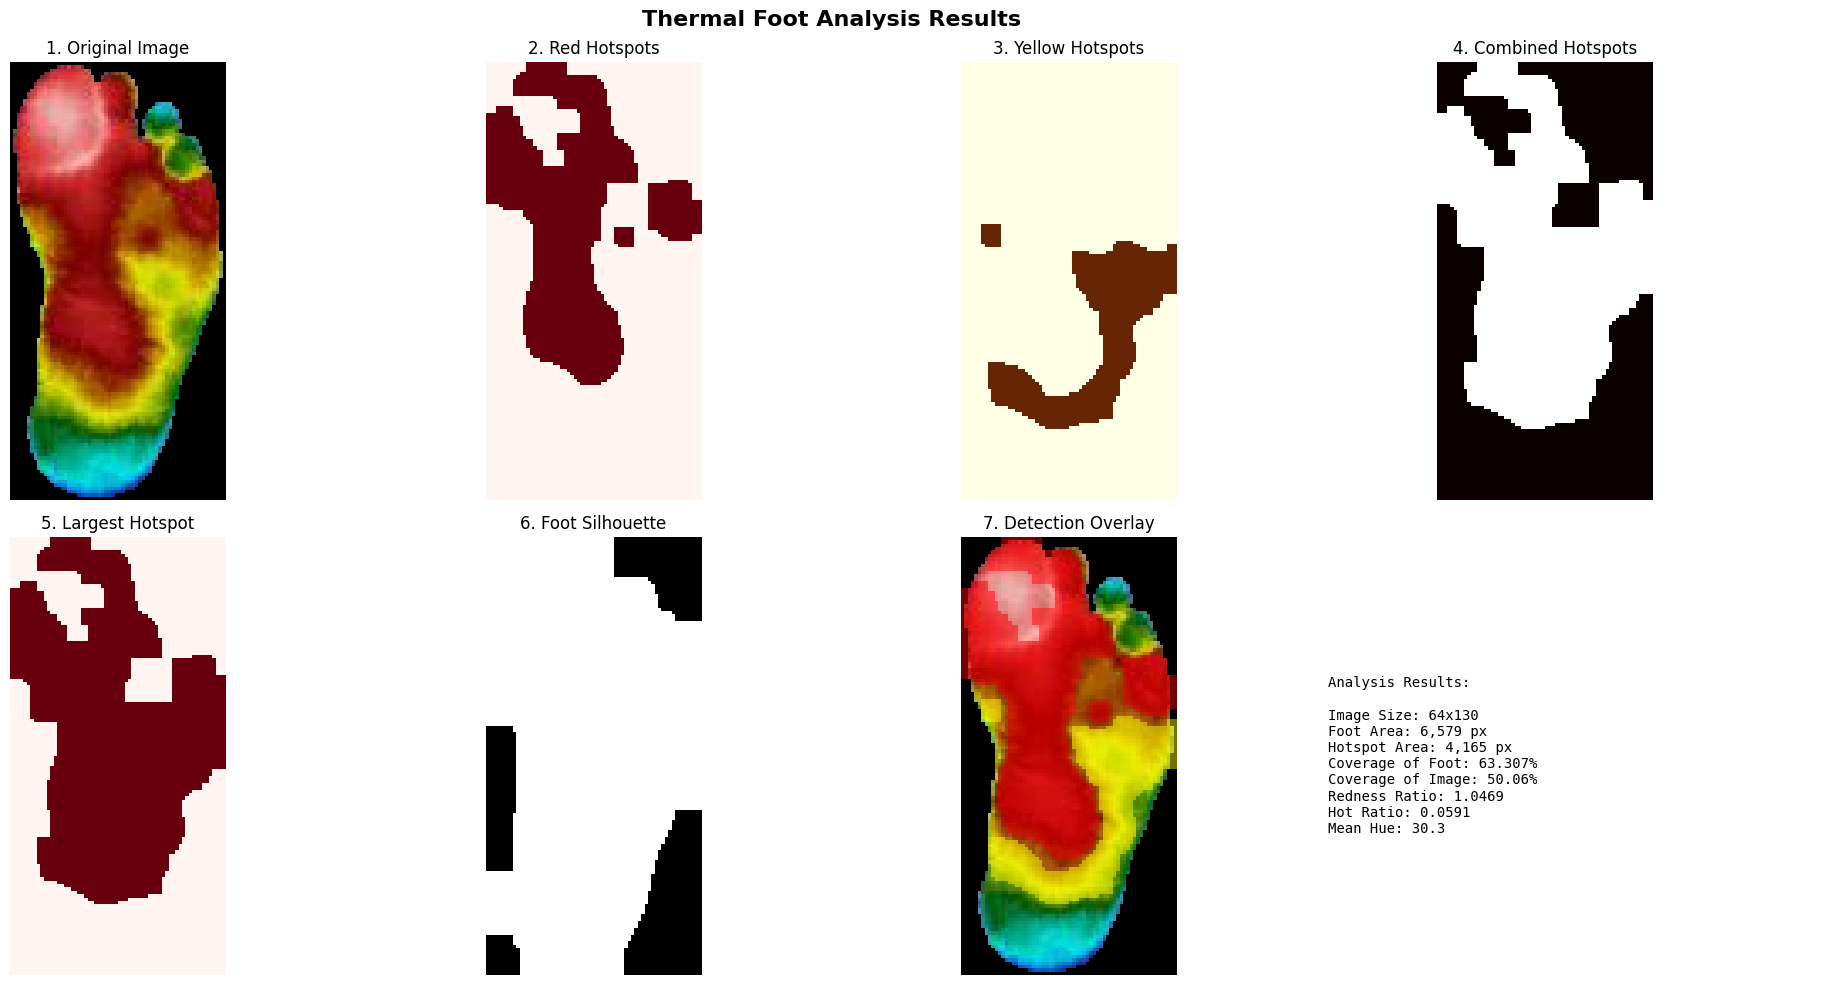


 Analysis Complete
Hotspot covers 63.307% of foot area
Hotspot covers 50.06% of image area
Redness ratio: 1.0469
Hot ratio: 0.0591

=== Detailed Results ===
image_path: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group/DM035_F_L.png
image_width: 64
image_height: 130
image_area_px: 8320
foot_area_px: 6579
largest_hotspot_area_px: 4165
hotspot_%_of_foot: 63.307
hotspot_%_of_image: 50.06
combined_total_px: 4165
hotspot_bbox: (0, 0, 64, 109)
redness_ratio: 1.0469266249399602
red_dominance: 0.1978120380400153
mean_hue: 30.26201923076923
hue_skewness: 2.0277302058704083
foot_hue_mean: 45.4739263803681
foot_area_ratio: 0.6269230769230769
hot_ratio_175: 0.05913461538461538


In [6]:
def extract_simple_features_from_img(img_bgr):
    """
    Extracts 7 simple color and threshold-based features from the BGR image.
    """
    features = {}
    
    # Pre-calculate common components
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    
    # 1. REDNESS FEATURES (Most important)
    b, g, r = cv2.split(img_bgr)
    features['redness_ratio'] = np.mean(r) / (np.mean(g) + np.mean(b) + 1e-6)
    features['red_dominance'] = (np.mean(r) - np.mean(g)) / (np.mean(r) + np.mean(g) + 1e-6)
    
    # 2. HUE FEATURES (2nd most important)
    hue = hsv[:, :, 0].flatten()
    features['mean_hue'] = np.mean(hue)
    features['hue_skewness'] = pd.Series(hue).skew()
    
    # 3. FOOT REGION ANALYSIS (New important feature)
    _, foot_mask = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
    foot_pixels = np.sum(foot_mask == 255)
    
    if foot_pixels > 0:
        foot_hue = hsv[foot_mask == 255, 0]
        features['foot_hue_mean'] = np.mean(foot_hue)
        features['foot_area_ratio'] = foot_pixels / gray.size
    else:
        features.update({'foot_hue_mean': 0, 'foot_area_ratio': 0})
    
    # 4. SIMPLE HOT SPOT DETECTION
    _, thresh_175 = cv2.threshold(gray, 175, 255, cv2.THRESH_BINARY)
    features['hot_ratio_175'] = np.sum(thresh_175 == 255) / gray.size
    
    # Only 7 features total - simple but powerful
    return features

# Core Image Processing Functions
def ensure_bin_uint8(mask):
    if mask.dtype != np.uint8:
        mask = mask.astype(np.uint8)
    _, m = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return m

def remove_small_components(mask, min_area=20):
    """Remove connected components smaller than min_area from binary mask (0/255)."""
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, num_labels):
        if stats[i, cv2.CC_STAT_AREA] >= min_area:
            out[labels == i] = 255
    return out

def get_largest_component(mask_white):
    """Extract largest connected component from binary mask."""
    bw = ensure_bin_uint8(mask_white)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(bw, connectivity=8)
    if num_labels <= 1:
        return np.zeros_like(bw), 0, None, None

    areas = stats[1:, cv2.CC_STAT_AREA]
    max_idx = int(np.argmax(areas))
    largest_label = max_idx + 1
    largest_area = int(areas[max_idx])

    largest_mask = np.zeros_like(bw)
    largest_mask[labels == largest_label] = 255

    contours, _ = cv2.findContours(largest_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        bbox = (x, y, w, h)
    else:
        largest_contour = None
        bbox = None

    return largest_mask, largest_area, bbox, largest_contour

def find_foot_silhouette_mask(img_bgr, threshold_val=10, min_area=5000, kernel_size=15):
    """Extract foot silhouette using thresholding and morphology."""
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, threshold_val, 255, cv2.THRESH_BINARY)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    foot_mask = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=1)
    foot_mask = remove_small_components(foot_mask, min_area=min_area)
    
    # Keep only largest component
    largest_mask, _, _, _ = get_largest_component(foot_mask)
    return largest_mask

def red_mask_hsv_from_path(image_path, s_thresh=120, v_thresh=70, kernel_size=5, min_area=20):
    """Extract red hotspots using HSV color space."""
    img = cv2.imread(image_path)
    if img is None:
        raise FileNotFoundError(f"Cannot load image: {image_path}")
    
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    lower1 = np.array([0, s_thresh, v_thresh], dtype=np.uint8)
    upper1 = np.array([10, 255, 255], dtype=np.uint8)
    lower2 = np.array([170, s_thresh, v_thresh], dtype=np.uint8)
    upper2 = np.array([180, 255, 255], dtype=np.uint8)
    
    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)
    mask = cv2.bitwise_or(mask1, mask2)
    
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = ensure_bin_uint8(mask)
    mask = remove_small_components(mask, min_area=min_area)
    
    return mask, img

def yellow_mask_hsv_from_img(img_bgr, lower_hue=18, upper_hue=40, s_thresh=100, v_thresh=100,
                             kernel_size=5, min_area=20):
    """Extract yellow hotspots using HSV color space."""
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([lower_hue, s_thresh, v_thresh], dtype=np.uint8)
    upper = np.array([upper_hue, 255, 255], dtype=np.uint8)
    
    raw = cv2.inRange(hsv, lower, upper)
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    clean = cv2.morphologyEx(raw, cv2.MORPH_CLOSE, kernel, iterations=1)
    clean = cv2.morphologyEx(clean, cv2.MORPH_OPEN, kernel, iterations=1)
    clean = ensure_bin_uint8(clean)
    clean = remove_small_components(clean, min_area=min_area)
    
    return clean

def combine_and_invert(red_white, yellow_white, close_kernel=5, min_area=40):
    """Combine red and yellow masks and create inverted version."""
    r = ensure_bin_uint8(red_white)
    y = ensure_bin_uint8(yellow_white)
    combined_white = cv2.bitwise_or(r, y)
    
    kernel = np.ones((close_kernel, close_kernel), np.uint8)
    combined_white = cv2.morphologyEx(combined_white, cv2.MORPH_CLOSE, kernel, iterations=1)
    combined_white = cv2.morphologyEx(combined_white, cv2.MORPH_OPEN, kernel, iterations=1)
    combined_white = remove_small_components(combined_white, min_area=min_area)
    combined_white = ensure_bin_uint8(combined_white)
    
    combined_inverted = cv2.bitwise_not(combined_white)  # hot = black
    return combined_white, combined_inverted

def overlay_hotspots_from_bgr(img_bgr, red_mask_white, yellow_mask_white, alpha=0.45):
    """
    Create overlay visualization of hotspots on original image
    Red regions: semi-transparent red overlay
    Yellow regions: semi-transparent yellow overlay
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    overlay = img_rgb.copy().astype(np.uint8)
    red_loc = red_mask_white == 255
    yellow_loc = yellow_mask_white == 255
    
    overlay[red_loc] = (overlay[red_loc] * (1 - alpha) + np.array([255, 0, 0]) * alpha).astype(np.uint8)
    overlay[yellow_loc] = (overlay[yellow_loc] * (1 - alpha) + np.array([255, 255, 0]) * alpha).astype(np.uint8)
    
    return overlay

# Single Image Analysis Pipeline (UPDATED with all features)
def analyze_single_image(image_path, 
                        red_s=120, red_v=70, 
                        yellow_h_low=18, yellow_h_high=40,
                        save_results=True, show_plots=True):
  
    try:
        print(f"Analyzing image: {os.path.basename(image_path)}")
        
        # 1) Extract red hotspots
        red_mask, img_bgr = red_mask_hsv_from_path(image_path, s_thresh=red_s, v_thresh=red_v)
        
        # 2) Extract yellow hotspots
        yellow_mask = yellow_mask_hsv_from_img(img_bgr, lower_hue=yellow_h_low, upper_hue=yellow_h_high)
        
        # 3) Combine masks
        combined_mask, combined_inverted = combine_and_invert(red_mask, yellow_mask)
        
        # 4) Find largest hotspot
        largest_mask, largest_area, hotspot_bbox, hotspot_contour = get_largest_component(combined_mask)
        
        # 5) Extract foot silhouette
        foot_mask = find_foot_silhouette_mask(img_bgr)
        foot_area = np.sum(foot_mask == 255)
        
        # 6) Calculate image properties
        img_h, img_w = img_bgr.shape[:2]
        img_area = img_w * img_h
        
        # 7) Calculate percentages
        hotspot_pct_foot = round(100.0 * largest_area / foot_area, 3) if foot_area > 0 else 0.0
        hotspot_pct_image = round(100.0 * largest_area / img_area, 3) if img_area > 0 else 0.0
        
        # 8) Extract color features (NEW - added to the function)
        color_features = extract_simple_features_from_img(img_bgr)
        
        # 9) Create overlay
        overlay = overlay_hotspots_from_bgr(img_bgr, red_mask, yellow_mask)
        
        # 10) Prepare results (UPDATED with all features)
        summary = {
            'image_path': image_path,
            'image_width': img_w,
            'image_height': img_h,
            'image_area_px': img_area,
            'foot_area_px': foot_area,
            'largest_hotspot_area_px': largest_area,
            'hotspot_%_of_foot': hotspot_pct_foot,
            'hotspot_%_of_image': hotspot_pct_image,
            'combined_total_px': np.sum(combined_mask == 255),
            'hotspot_bbox': hotspot_bbox,
            # Color features added below
            'redness_ratio': color_features['redness_ratio'],
            'red_dominance': color_features['red_dominance'],
            'mean_hue': color_features['mean_hue'],
            'hue_skewness': color_features['hue_skewness'],
            'foot_hue_mean': color_features['foot_hue_mean'],
            'foot_area_ratio': color_features['foot_area_ratio'],
            'hot_ratio_175': color_features['hot_ratio_175']
        }
        
        masks = {
            'original': img_bgr,
            'red_mask': red_mask,
            'yellow_mask': yellow_mask,
            'combined_mask': combined_mask,
            'largest_hotspot': largest_mask,
            'foot_silhouette': foot_mask,
            'overlay': overlay
        }
    
        # 11) Display results if requested
        if show_plots:
            display_analysis_results(summary, masks)
        
        print("\n Analysis Complete")
        print(f"Hotspot covers {hotspot_pct_foot}% of foot area")
        print(f"Hotspot covers {hotspot_pct_image}% of image area")
        print(f"Redness ratio: {color_features['redness_ratio']:.4f}")
        print(f"Hot ratio: {color_features['hot_ratio_175']:.4f}")
        
        return summary, masks
        
    except Exception as e:
        print(f"Error analyzing image: {e}")
        traceback.print_exc()
        return None, None

def display_analysis_results(summary, masks):
    """Display analysis results using matplotlib."""
    # Create a comprehensive visualization
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    fig.suptitle('Thermal Foot Analysis Results', fontsize=16, fontweight='bold')
    
    # Original image
    img_rgb = cv2.cvtColor(masks['original'], cv2.COLOR_BGR2RGB)
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('1. Original Image')
    axes[0, 0].axis('off')
    
    # Red mask
    axes[0, 1].imshow(masks['red_mask'], cmap='Reds')
    axes[0, 1].set_title('2. Red Hotspots')
    axes[0, 1].axis('off')
    
    # Yellow mask
    axes[0, 2].imshow(masks['yellow_mask'], cmap='YlOrBr')
    axes[0, 2].set_title('3. Yellow Hotspots')
    axes[0, 2].axis('off')
    
    # Combined mask
    axes[0, 3].imshow(masks['combined_mask'], cmap='hot')
    axes[0, 3].set_title('4. Combined Hotspots')
    axes[0, 3].axis('off')
    
    # Largest hotspot
    axes[1, 0].imshow(masks['largest_hotspot'], cmap='Reds')
    axes[1, 0].set_title('5. Largest Hotspot')
    axes[1, 0].axis('off')
    
    # Foot silhouette
    axes[1, 1].imshow(masks['foot_silhouette'], cmap='gray')
    axes[1, 1].set_title('6. Foot Silhouette')
    axes[1, 1].axis('off')
    
    # Overlay
    axes[1, 2].imshow(masks['overlay'])
    axes[1, 2].set_title('7. Detection Overlay')
    axes[1, 2].axis('off')
    
    # Statistics (UPDATED with color features)
    axes[1, 3].axis('off')
    stats_text = f"Analysis Results:\n\n"
    stats_text += f"Image Size: {summary['image_width']}x{summary['image_height']}\n"
    stats_text += f"Foot Area: {summary['foot_area_px']:,} px\n"
    stats_text += f"Hotspot Area: {summary['largest_hotspot_area_px']:,} px\n"
    stats_text += f"Coverage of Foot: {summary['hotspot_%_of_foot']}%\n"
    stats_text += f"Coverage of Image: {summary['hotspot_%_of_image']}%\n"
    stats_text += f"Redness Ratio: {summary['redness_ratio']:.4f}\n"
    stats_text += f"Hot Ratio: {summary['hot_ratio_175']:.4f}\n"
    stats_text += f"Mean Hue: {summary['mean_hue']:.1f}"
    
    axes[1, 3].text(0.1, 0.5, stats_text, transform=axes[1, 3].transAxes, 
                   fontsize=10, fontfamily='monospace', verticalalignment='center')
    
    plt.tight_layout()
    plt.show()


summary, masks = analyze_single_image(image_path=file_path, save_results=False, show_plots=True)

if summary:
    print("\n=== Detailed Results ===")
    for key, value in summary.items():
        print(f"{key}: {value}")

# Extracting the values from each image of folder and creating CSV file

In [7]:
import cv2
import numpy as np
import pandas as pd
import os
from glob import glob

def batch_process_folder_silent(folder_path, output_csv):
    """
    Batch process all images in a folder and save results to CSV without printing
    """
    # Find all image files
    patterns = ['*.png', '*.jpg', '*.jpeg', '*.tif', '*.bmp']
    image_files = []
    for pattern in patterns:
        image_files.extend(glob(os.path.join(folder_path, pattern)))
    
    if not image_files:
        print(f"No images found in {folder_path}")
        return
    
    all_results = []
    
    for image_path in image_files:
        try:
            # Analyze single image with all printing disabled
            summary, masks = analyze_single_image(
                image_path=image_path,
                save_results=False,
                show_plots=False  # Disable plots
            )
            
            if summary:
                all_results.append(summary)
                
        except Exception as e:
            # Just continue to next image if there's an error
            continue
    
    # Create DataFrame and save to CSV
    if all_results:
        df = pd.DataFrame(all_results)
        df.to_csv(output_csv, index=False)
        print(f"Saved {len(all_results)} results to: {output_csv}")
    else:
        print(f"No successful processing for: {folder_path}")

# Modified analyze_single_image function to suppress output
def analyze_single_image(image_path, 
                        red_s=120, red_v=70, 
                        yellow_h_low=18, yellow_h_high=40,
                        save_results=True, show_plots=True):
  
    try:
        # 1) Extract red hotspots
        red_mask, img_bgr = red_mask_hsv_from_path(image_path, s_thresh=red_s, v_thresh=red_v)
        
        # 2) Extract yellow hotspots
        yellow_mask = yellow_mask_hsv_from_img(img_bgr, lower_hue=yellow_h_low, upper_hue=yellow_h_high)
        
        # 3) Combine masks
        combined_mask, combined_inverted = combine_and_invert(red_mask, yellow_mask)
        
        # 4) Find largest hotspot
        largest_mask, largest_area, hotspot_bbox, hotspot_contour = get_largest_component(combined_mask)
        
        # 5) Extract foot silhouette
        foot_mask = find_foot_silhouette_mask(img_bgr)
        foot_area = np.sum(foot_mask == 255)
        
        # 6) Calculate image properties
        img_h, img_w = img_bgr.shape[:2]
        img_area = img_w * img_h
        
        # 7) Calculate percentages
        hotspot_pct_foot = round(100.0 * largest_area / foot_area, 3) if foot_area > 0 else 0.0
        hotspot_pct_image = round(100.0 * largest_area / img_area, 3) if img_area > 0 else 0.0
        
        # 8) Extract color features
        color_features = extract_simple_features_from_img(img_bgr)
        
        # 9) Create overlay
        overlay = overlay_hotspots_from_bgr(img_bgr, red_mask, yellow_mask)
        
        # 10) Prepare results with all features
        summary = {
            'image_path': image_path,
            'image_width': img_w,
            'image_height': img_h,
            'image_area_px': img_area,
            'foot_area_px': foot_area,
            'largest_hotspot_area_px': largest_area,
            'hotspot_%_of_foot': hotspot_pct_foot,
            'hotspot_%_of_image': hotspot_pct_image,
            'combined_total_px': np.sum(combined_mask == 255),
            'hotspot_bbox': str(hotspot_bbox),  # Convert tuple to string for CSV
            # Color features
            'redness_ratio': color_features['redness_ratio'],
            'red_dominance': color_features['red_dominance'],
            'mean_hue': color_features['mean_hue'],
            'hue_skewness': color_features['hue_skewness'],
            'foot_hue_mean': color_features['foot_hue_mean'],
            'foot_area_ratio': color_features['foot_area_ratio'],
            'hot_ratio_175': color_features['hot_ratio_175']
        }
        
        masks = {
            'original': img_bgr,
            'red_mask': red_mask,
            'yellow_mask': yellow_mask,
            'combined_mask': combined_mask,
            'largest_hotspot': largest_mask,
            'foot_silhouette': foot_mask,
            'overlay': overlay
        }
    
        return summary, masks
        
    except Exception as e:
        return None, None

# Process all 4 folders
def process_all_folders():
    """Process all 4 folders and create CSV files"""
    
    # Define all paths
    folders = [
        ("/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group", "train_dm_group.csv"),
        ("/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/Control Group", "train_control_group.csv"),
        ("/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group", "val_dm_group.csv"),
        ("/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/Control Group", "val_control_group.csv")
    ]
    
    print("Starting batch processing for 4 folders...")
    
    for folder_path, output_csv in folders:
        print(f"\n Processing: {folder_path}")
        batch_process_folder_silent(folder_path, output_csv)
    
    print("\n All CSV files created successfully!")
    print("Generated files:")
    for _, output_csv in folders:
        print(f"  - {output_csv}")


process_all_folders()

Starting batch processing for 4 folders...

 Processing: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group
Saved 724 results to: train_dm_group.csv

 Processing: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/Control Group
Saved 720 results to: train_control_group.csv

 Processing: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/DM Group
Saved 252 results to: val_dm_group.csv

 Processing: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val/Control Group
Saved 170 results to: val_control_group.csv

 All CSV files created successfully!
Generated files:
  - train_dm_group.csv
  - train_control_group.csv
  - val_dm_group.csv
  - val_control_group.csv


# Removing outliers by analysing the collected data

Loading and processing TRAIN dataset...
Train DM Group: 724 images
Train Control Group: 720 images

=== DM Group (Train) Detailed Summary ===
num_images: 724
successful: 724
min_hotspot_px: 0
min_image: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group/DM065_F_L-rotated2.png
max_hotspot_px: 39076
max_image: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group/DM119_F_L-rotated1.png
mean_hotspot_px: 15200.75552486188
median_hotspot_px: 13482.0
std_hotspot_px: 12784.790580627236
min_hotspot_%_of_foot: 0.0
min_pct_foot_image: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group/DM065_F_L-rotated2.png
max_hotspot_%_of_foot: 96.176
max_pct_foot_image: /kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train/DM Group/DM119_F_L-rotated2.png
mean_hotspot_%_of_foot: 49.3498232

/tmp/ipykernel_23/2950096270.py:126: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0,1].boxplot(box_data, labels=box_labels, patch_artist=True,
/tmp/ipykernel_23/2950096270.py:138: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_data, x='group', y='hotspot_%_of_foot', ax=axes[0,2], palette=['red', 'blue'])


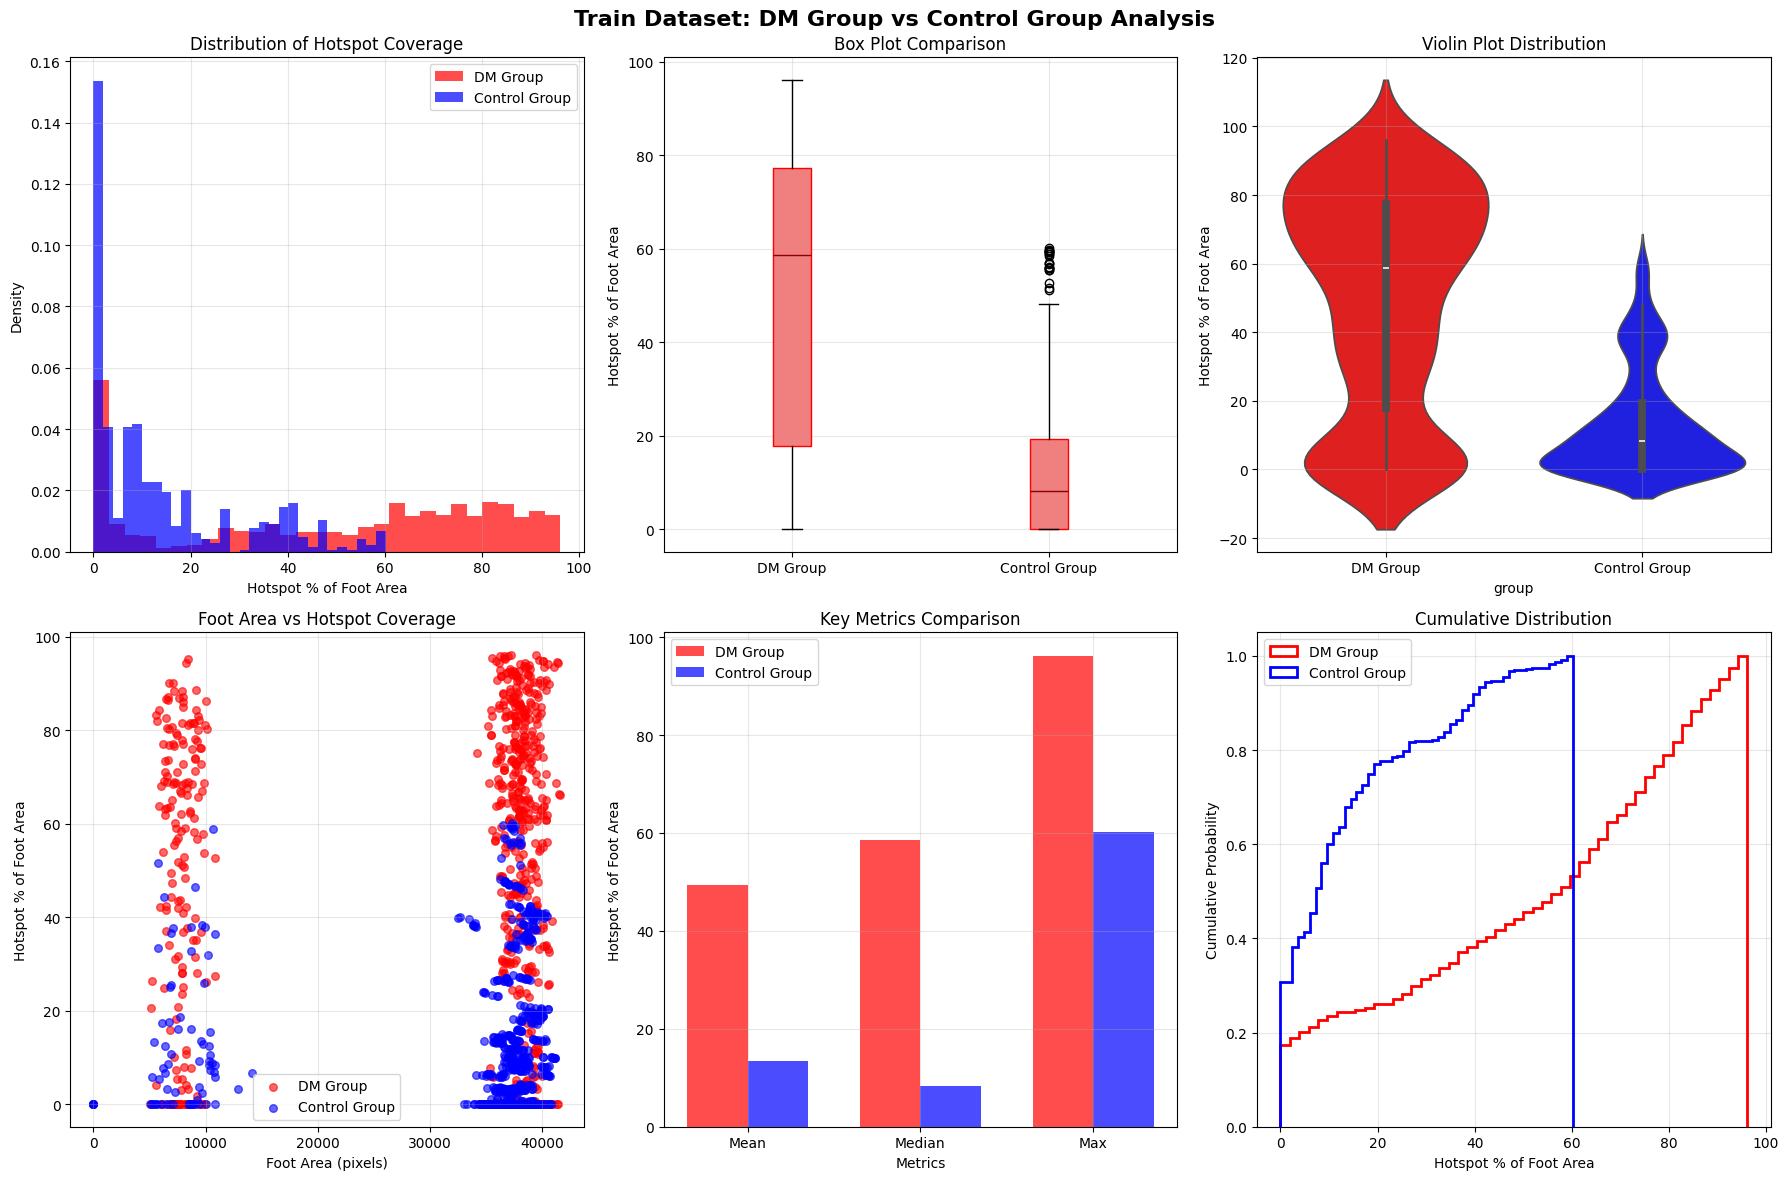

SIGNIFICANT HOTSPOTS ANALYSIS (> 10.0%) ===
DM Group: 560 images (77.3%) with hotspots > 10.0%
Control Group: 308 images (42.8%) with hotspots > 10.0%


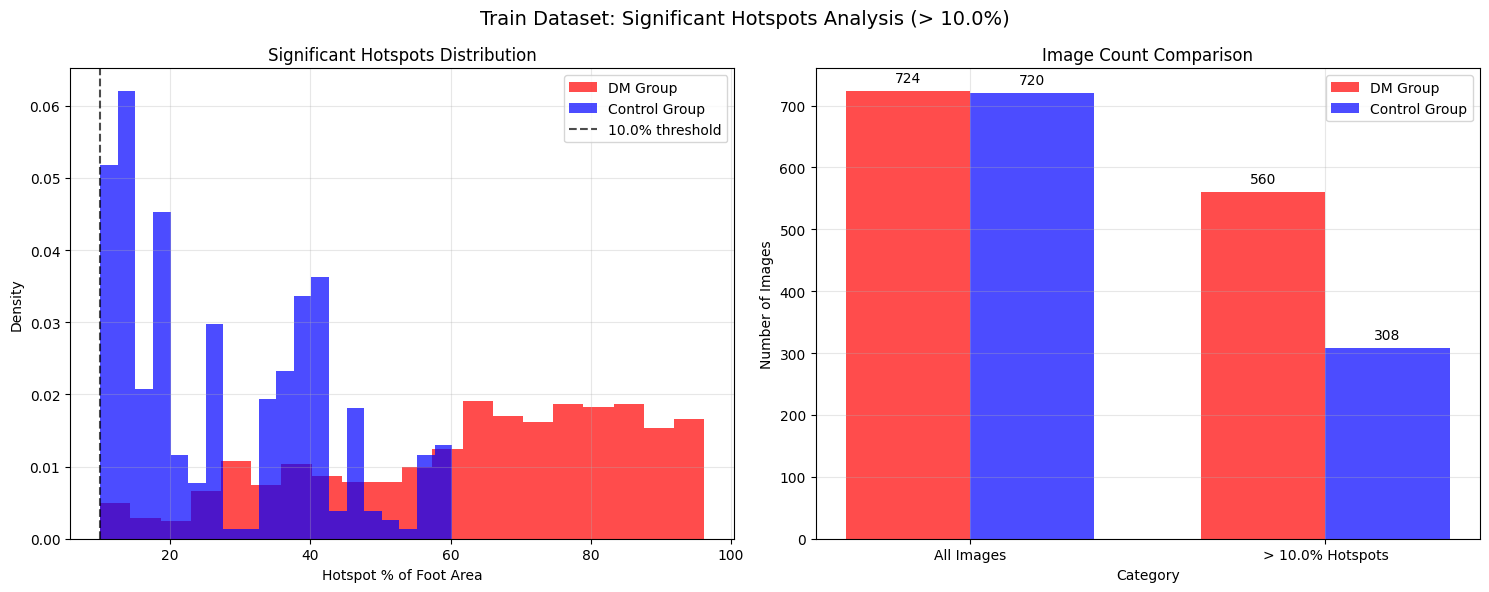

STATISTICAL ANALYSIS (TRAIN DATASET)
T-test: t-statistic = 26.6484, p-value = 0.000000
Mann-Whitney U test: U-statistic = 409529.5000, p-value = 0.000000
 Statistically significant difference between groups (p < 0.05)
Effect size (Cohen's d): 1.4038


In [8]:
# Set style for better plots
plt.style.use('default')
sns.set_palette("husl")

def load_train_data():
    """
    Load only train dataset CSV files
    """
    # Load train CSV files
    train_dm = pd.read_csv('train_dm_group.csv')
    train_control = pd.read_csv('train_control_group.csv')
    
    # Add group labels
    train_dm['group'] = 'DM Group'
    train_control['group'] = 'Control Group'
    
    print(f"Train DM Group: {len(train_dm)} images")
    print(f"Train Control Group: {len(train_control)} images")
    
    return train_dm, train_control

def calculate_summary_statistics(df, group_name):
    """
    Calculate comprehensive summary statistics for a group
    """
    # Filter valid numeric data
    df_valid = df[df['largest_hotspot_area_px'].apply(lambda x: isinstance(x, (int, np.integer)))]
    
    if df_valid.empty:
        return None
    
    # Basic statistics
    summary = {
        'group_name': group_name,
        'num_images': len(df),
        'successful': len(df_valid),
        'min_hotspot_px': int(df_valid['largest_hotspot_area_px'].min()),
        'min_image': df_valid.loc[df_valid['largest_hotspot_area_px'].idxmin(), 'image_path'],
        'max_hotspot_px': int(df_valid['largest_hotspot_area_px'].max()),
        'max_image': df_valid.loc[df_valid['largest_hotspot_area_px'].idxmax(), 'image_path'],
        'mean_hotspot_px': float(df_valid['largest_hotspot_area_px'].mean()),
        'median_hotspot_px': float(df_valid['largest_hotspot_area_px'].median()),
        'std_hotspot_px': float(df_valid['largest_hotspot_area_px'].std()),
        'min_hotspot_%_of_foot': float(df_valid['hotspot_%_of_foot'].min()),
        'min_pct_foot_image': df_valid.loc[df_valid['hotspot_%_of_foot'].idxmin(), 'image_path'],
        'max_hotspot_%_of_foot': float(df_valid['hotspot_%_of_foot'].max()),
        'max_pct_foot_image': df_valid.loc[df_valid['hotspot_%_of_foot'].idxmax(), 'image_path'],
        'mean_hotspot_%_of_foot': float(df_valid['hotspot_%_of_foot'].mean()),
        'median_hotspot_%_of_foot': float(df_valid['hotspot_%_of_foot'].median()),
        'std_hotspot_%_of_foot': float(df_valid['hotspot_%_of_foot'].std())
    }
    
    return summary

def print_detailed_summary(summary):
    """
    Print detailed summary statistics in the format you specified
    """
    print(f"\n=== {summary['group_name']} Detailed Summary ===")
    for key, value in summary.items():
        if key not in ['group_name']:
            print(f"{key}: {value}")

def compare_groups(dm_summary, ctrl_summary):
    """
    Compare DM Group vs Control Group statistics
    """
    print("COMPARATIVE ANALYSIS: DM Group vs Control Group (TRAIN DATASET)")
    
    
    # Calculate differences
    mean_pct_diff = dm_summary['mean_hotspot_%_of_foot'] - ctrl_summary['mean_hotspot_%_of_foot']
    median_pct_diff = dm_summary['median_hotspot_%_of_foot'] - ctrl_summary['median_hotspot_%_of_foot']
    
    print(f"\nMean Hotspot % of Foot:")
    print(f"  DM Group:     {dm_summary['mean_hotspot_%_of_foot']:.2f}%")
    print(f"  Control Group: {ctrl_summary['mean_hotspot_%_of_foot']:.2f}%")
    print(f"  Difference:   {mean_pct_diff:+.2f}%")
    
    print(f"\nMedian Hotspot % of Foot:")
    print(f"  DM Group:     {dm_summary['median_hotspot_%_of_foot']:.2f}%")
    print(f"  Control Group: {ctrl_summary['median_hotspot_%_of_foot']:.2f}%")
    print(f"  Difference:   {median_pct_diff:+.2f}%")
    
    print(f"\nMaximum Hotspot % of Foot:")
    print(f"  DM Group:     {dm_summary['max_hotspot_%_of_foot']:.2f}%")
    print(f"  Control Group: {ctrl_summary['max_hotspot_%_of_foot']:.2f}%")
    
    print(f"\nSample Sizes:")
    print(f"  DM Group:     {dm_summary['successful']} images")
    print(f"  Control Group: {ctrl_summary['successful']} images")
    
    return {
        'DM_Group': dm_summary,
        'Control_Group': ctrl_summary,
        'mean_pct_diff': mean_pct_diff,
        'median_pct_diff': median_pct_diff
    }

def filter_significant_hotspots(df, threshold_pct=10.0):
    """
    Filter dataframe to include only images with hotspot % greater than threshold
    """
    df_filtered = df[df['hotspot_%_of_foot'] > threshold_pct].copy()
    return df_filtered

def plot_comprehensive_comparison(dm_df, ctrl_df, dm_summary, ctrl_summary):
    """
    Create comprehensive comparative visualization for train dataset
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('Train Dataset: DM Group vs Control Group Analysis', fontsize=16, fontweight='bold')
    
    # Plot 1: Distribution of Hotspot % of Foot
    axes[0,0].hist(dm_df['hotspot_%_of_foot'], alpha=0.7, label='DM Group', bins=30, color='red', density=True)
    axes[0,0].hist(ctrl_df['hotspot_%_of_foot'], alpha=0.7, label='Control Group', bins=30, color='blue', density=True)
    axes[0,0].set_xlabel('Hotspot % of Foot Area')
    axes[0,0].set_ylabel('Density')
    axes[0,0].set_title('Distribution of Hotspot Coverage')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Plot 2: Box plot comparison
    box_data = [dm_df['hotspot_%_of_foot'], ctrl_df['hotspot_%_of_foot']]
    box_labels = ['DM Group', 'Control Group']
    axes[0,1].boxplot(box_data, labels=box_labels, patch_artist=True,
                     boxprops=dict(facecolor='lightcoral', color='red'),
                     medianprops=dict(color='darkred'))
    axes[0,1].set_ylabel('Hotspot % of Foot Area')
    axes[0,1].set_title('Box Plot Comparison')
    axes[0,1].grid(True, alpha=0.3)
    
    # Plot 3: Violin plot for better distribution visualization
    combined_data = pd.concat([
        dm_df[['hotspot_%_of_foot', 'group']],
        ctrl_df[['hotspot_%_of_foot', 'group']]
    ])
    sns.violinplot(data=combined_data, x='group', y='hotspot_%_of_foot', ax=axes[0,2], palette=['red', 'blue'])
    axes[0,2].set_title('Violin Plot Distribution')
    axes[0,2].set_ylabel('Hotspot % of Foot Area')
    axes[0,2].grid(True, alpha=0.3)
    
    # Plot 4: Scatter plot - foot area vs hotspot %
    axes[1,0].scatter(dm_df['foot_area_px'], dm_df['hotspot_%_of_foot'], 
                     alpha=0.6, label='DM Group', color='red', s=30)
    axes[1,0].scatter(ctrl_df['foot_area_px'], ctrl_df['hotspot_%_of_foot'], 
                     alpha=0.6, label='Control Group', color='blue', s=30)
    axes[1,0].set_xlabel('Foot Area (pixels)')
    axes[1,0].set_ylabel('Hotspot % of Foot Area')
    axes[1,0].set_title('Foot Area vs Hotspot Coverage')
    axes[1,0].legend()
    axes[1,0].grid(True, alpha=0.3)
    
    # Plot 5: Bar chart of key metrics
    metrics = ['Mean', 'Median', 'Max']
    dm_values = [
        dm_summary['mean_hotspot_%_of_foot'],
        dm_summary['median_hotspot_%_of_foot'], 
        dm_summary['max_hotspot_%_of_foot']
    ]
    ctrl_values = [
        ctrl_summary['mean_hotspot_%_of_foot'],
        ctrl_summary['median_hotspot_%_of_foot'],
        ctrl_summary['max_hotspot_%_of_foot']
    ]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    axes[1,1].bar(x - width/2, dm_values, width, label='DM Group', color='red', alpha=0.7)
    axes[1,1].bar(x + width/2, ctrl_values, width, label='Control Group', color='blue', alpha=0.7)
    axes[1,1].set_xlabel('Metrics')
    axes[1,1].set_ylabel('Hotspot % of Foot Area')
    axes[1,1].set_title('Key Metrics Comparison')
    axes[1,1].set_xticks(x)
    axes[1,1].set_xticklabels(metrics)
    axes[1,1].legend()
    axes[1,1].grid(True, alpha=0.3)
    
    # Plot 6: Cumulative distribution
    axes[1,2].hist(dm_df['hotspot_%_of_foot'], bins=50, density=True, cumulative=True, 
                  histtype='step', linewidth=2, label='DM Group', color='red')
    axes[1,2].hist(ctrl_df['hotspot_%_of_foot'], bins=50, density=True, cumulative=True, 
                  histtype='step', linewidth=2, label='Control Group', color='blue')
    axes[1,2].set_xlabel('Hotspot % of Foot Area')
    axes[1,2].set_ylabel('Cumulative Probability')
    axes[1,2].set_title('Cumulative Distribution')
    axes[1,2].legend()
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('train_dataset_comprehensive_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()

def plot_significant_hotspots_analysis(dm_df, ctrl_df, threshold_pct=10.0):
    """
    Analyze and visualize significant hotspots for train dataset
    """
    dm_significant = filter_significant_hotspots(dm_df, threshold_pct)
    ctrl_significant = filter_significant_hotspots(ctrl_df, threshold_pct)
    
    # Calculate statistics
    dm_sig_stats = {
        'mean': dm_significant['hotspot_%_of_foot'].mean(),
        'median': dm_significant['hotspot_%_of_foot'].median(),
        'max': dm_significant['hotspot_%_of_foot'].max(),
        'count': len(dm_significant),
        'percentage': len(dm_significant) / len(dm_df) * 100
    }
    
    ctrl_sig_stats = {
        'mean': ctrl_significant['hotspot_%_of_foot'].mean(),
        'median': ctrl_significant['hotspot_%_of_foot'].median(),
        'max': ctrl_significant['hotspot_%_of_foot'].max(),
        'count': len(ctrl_significant),
        'percentage': len(ctrl_significant) / len(ctrl_df) * 100
    }
    
    print(f"SIGNIFICANT HOTSPOTS ANALYSIS (> {threshold_pct}%) ===")
    print(f"DM Group: {dm_sig_stats['count']} images ({dm_sig_stats['percentage']:.1f}%) with hotspots > {threshold_pct}%")
    print(f"Control Group: {ctrl_sig_stats['count']} images ({ctrl_sig_stats['percentage']:.1f}%) with hotspots > {threshold_pct}%")
    
    # Create visualization
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle(f'Train Dataset: Significant Hotspots Analysis (> {threshold_pct}%)', fontsize=14)
    
    # Plot 1: Distribution of significant hotspots
    if not dm_significant.empty:
        axes[0].hist(dm_significant['hotspot_%_of_foot'], alpha=0.7, label='DM Group', bins=20, color='red', density=True)
    if not ctrl_significant.empty:
        axes[0].hist(ctrl_significant['hotspot_%_of_foot'], alpha=0.7, label='Control Group', bins=20, color='blue', density=True)
    axes[0].axvline(x=threshold_pct, color='black', linestyle='--', alpha=0.7, label=f'{threshold_pct}% threshold')
    axes[0].set_xlabel('Hotspot % of Foot Area')
    axes[0].set_ylabel('Density')
    axes[0].set_title(f'Significant Hotspots Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Percentage comparison
    categories = ['All Images', f'> {threshold_pct}% Hotspots']
    dm_counts = [len(dm_df), dm_sig_stats['count']]
    ctrl_counts = [len(ctrl_df), ctrl_sig_stats['count']]
    
    x = np.arange(len(categories))
    width = 0.35
    
    axes[1].bar(x - width/2, dm_counts, width, label='DM Group', color='red', alpha=0.7)
    axes[1].bar(x + width/2, ctrl_counts, width, label='Control Group', color='blue', alpha=0.7)
    axes[1].set_xlabel('Category')
    axes[1].set_ylabel('Number of Images')
    axes[1].set_title('Image Count Comparison')
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(categories)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Add value labels on bars
    for i, v in enumerate(dm_counts):
        axes[1].text(i - width/2, v + 10, str(v), ha='center', va='bottom')
    for i, v in enumerate(ctrl_counts):
        axes[1].text(i + width/2, v + 10, str(v), ha='center', va='bottom')
    
    plt.tight_layout()
    plt.savefig(f'train_dataset_significant_hotspots_{threshold_pct}pct.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return dm_significant, ctrl_significant, dm_sig_stats, ctrl_sig_stats

def statistical_analysis(dm_df, ctrl_df):
    """
    Perform statistical tests between groups for train dataset
    """
    print("STATISTICAL ANALYSIS (TRAIN DATASET)")
    
    # T-test for mean difference
    t_stat, p_value = stats.ttest_ind(dm_df['hotspot_%_of_foot'], ctrl_df['hotspot_%_of_foot'])
    
    # Mann-Whitney U test for distribution difference
    u_stat, u_pvalue = stats.mannwhitneyu(dm_df['hotspot_%_of_foot'], ctrl_df['hotspot_%_of_foot'])
    
    print(f"T-test: t-statistic = {t_stat:.4f}, p-value = {p_value:.6f}")
    print(f"Mann-Whitney U test: U-statistic = {u_stat:.4f}, p-value = {u_pvalue:.6f}")
    
    if p_value < 0.05:
        print(" Statistically significant difference between groups (p < 0.05)")
    else:
        print(" No statistically significant difference between groups (p >= 0.05)")
    
    # Effect size
    cohens_d = (dm_df['hotspot_%_of_foot'].mean() - ctrl_df['hotspot_%_of_foot'].mean()) / np.sqrt(
        (dm_df['hotspot_%_of_foot'].std()**2 + ctrl_df['hotspot_%_of_foot'].std()**2) / 2
    )
    print(f"Effect size (Cohen's d): {cohens_d:.4f}")

# Main analysis function for train dataset only
def run_train_dataset_analysis():
    """
    Run complete analysis pipeline for train dataset only
    """
    print("Loading and processing TRAIN dataset...")
    
    # Load only train data
    dm_df, ctrl_df = load_train_data()
    
    # Calculate summaries
    dm_summary = calculate_summary_statistics(dm_df, "DM Group (Train)")
    ctrl_summary = calculate_summary_statistics(ctrl_df, "Control Group (Train)")
    
    # Print detailed summaries
    print_detailed_summary(dm_summary)
    print_detailed_summary(ctrl_summary)
    
    # Compare groups
    comparison = compare_groups(dm_summary, ctrl_summary)
    
    # Create comprehensive visualizations
    print("\nCreating comprehensive visualizations for train dataset...")
    plot_comprehensive_comparison(dm_df, ctrl_df, dm_summary, ctrl_summary)
    
    # Analyze significant hotspots
    dm_sig, ctrl_sig, dm_sig_stats, ctrl_sig_stats = plot_significant_hotspots_analysis(dm_df, ctrl_df, threshold_pct=10.0)
    
    # Perform statistical analysis
    statistical_analysis(dm_df, ctrl_df)
 
    return dm_df, ctrl_df, dm_summary, ctrl_summary, comparison


dm_df, ctrl_df, dm_summary, ctrl_summary, comparison = run_train_dataset_analysis()

# Finding optimal threshould from training dataset

OPTIMAL THRESHOLD FINDING (TRAINING DATA ONLY)
Training samples: 1444
DM Group (Foot Ulcer): 724
Control Group: 720

 APPLYING DATA FILTER: Removing hotspots ≤ 10%

Filtering: Removed 576 images with hotspot ≤ 10.0%
Remaining training samples: 868
DM Group after filtering: 560
Control Group after filtering: 308
FINDING OPTIMAL THRESHOLD ON TRAINING DATA

Optimal thresholds found on training data:
Best Accuracy:  42.40% - Acc: 0.811, F1: 0.842
Best F1-Score:  27.30% - Acc: 0.802, F1: 0.858
Best Youden's J: 48.20% - Youden: 0.666
DETAILED ANALYSIS: 25-35% RANGE

Best in 25-35% range:
Best Accuracy: 27.30%
  - Accuracy: 0.802
  - F1-Score: 0.858
  - Sensitivity: 0.927
  - Specificity: 0.575

Best F1-Score: 27.30%
  - Accuracy: 0.802
  - F1-Score: 0.858
  - Sensitivity: 0.927
  - Specificity: 0.575


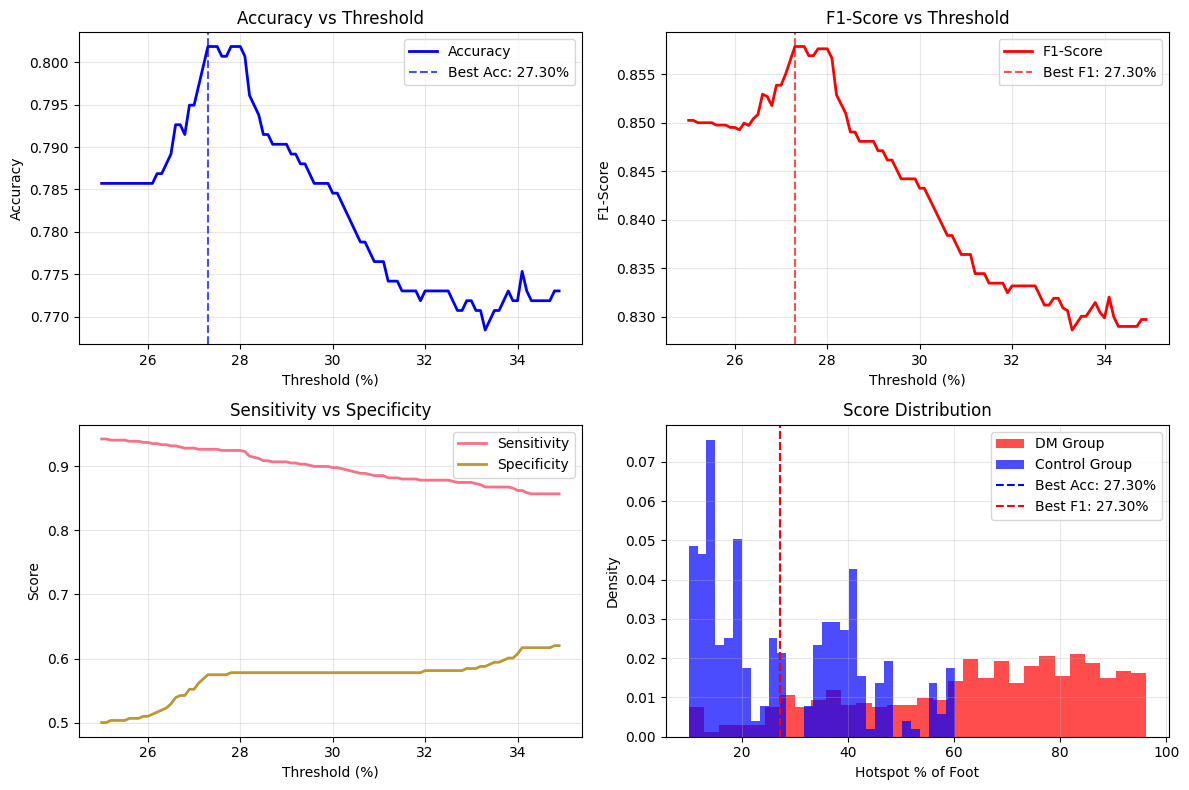

FINAL THRESHOLD RECOMMENDATION
 RECOMMENDED THRESHOLD: 27.30%
 Reason: Balances accuracy and F1-score effectively

 Expected performance at this threshold:
   - Accuracy:    80.2%
   - F1-Score:    0.858
   - Sensitivity: 92.7%
   - Specificity: 57.5%
 This threshold will be used for evaluation on validation/test data
 Save this threshold: 27.30%

 Optimal threshold found: 27.30%
You can now use this threshold to evaluate on validation/test data


In [9]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def load_train_data():
    """
    Load only training dataset
    """
    # Load train CSV files
    train_dm = pd.read_csv('train_dm_group.csv')
    train_control = pd.read_csv('train_control_group.csv')
    
    # Add labels (1 for DM with foot ulcer, 0 for control)
    train_dm['label'] = 1
    train_control['label'] = 0
    
    # Combine datasets
    train_data = pd.concat([train_dm, train_control], ignore_index=True)
    
    print(f"Training samples: {len(train_data)}")
    print(f"DM Group (Foot Ulcer): {len(train_dm)}")
    print(f"Control Group: {len(train_control)}")
    
    return train_data

def filter_low_hotspots(data, min_threshold=10.0):
    """
    Filter out images with hotspot coverage below threshold
    """
    original_size = len(data)
    filtered_data = data[data['hotspot_%_of_foot'] > min_threshold].copy()
    
    print(f"\nFiltering: Removed {original_size - len(filtered_data)} images with hotspot ≤ {min_threshold}%")
    print(f"Remaining training samples: {len(filtered_data)}")
    print(f"DM Group after filtering: {len(filtered_data[filtered_data['label'] == 1])}")
    print(f"Control Group after filtering: {len(filtered_data[filtered_data['label'] == 0])}")
    
    return filtered_data

def find_optimal_threshold_on_train(data, feature='hotspot_%_of_foot'):
    """
    Find optimal threshold using only training data
    """
    print("FINDING OPTIMAL THRESHOLD ON TRAINING DATA")
    
    y_true = data['label']
    y_scores = data[feature]
    
    # Test a wide range of thresholds
    thresholds = np.arange(0, 100, 0.1)
    results = []
    
    for threshold in thresholds:
        predictions = (y_scores > threshold).astype(int)
        
        accuracy = accuracy_score(y_true, predictions)
        f1 = f1_score(y_true, predictions, zero_division=0)
        precision = precision_score(y_true, predictions, zero_division=0)
        recall = recall_score(y_true, predictions, zero_division=0)
        
        # Youden's J statistic (sensitivity + specificity - 1)
        cm = confusion_matrix(y_true, predictions)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden_j = sensitivity + specificity - 1
        else:
            youden_j = 0
        
        results.append({
            'threshold': threshold,
            'accuracy': accuracy,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'youden_j': youden_j
        })
    
    results_df = pd.DataFrame(results)
    
    # Find optimal thresholds using different criteria
    optimal_accuracy = results_df.loc[results_df['accuracy'].idxmax()]
    optimal_f1 = results_df.loc[results_df['f1_score'].idxmax()]
    optimal_youden = results_df.loc[results_df['youden_j'].idxmax()]
    
    print(f"\nOptimal thresholds found on training data:")
    print(f"Best Accuracy:  {optimal_accuracy['threshold']:.2f}% - Acc: {optimal_accuracy['accuracy']:.3f}, F1: {optimal_accuracy['f1_score']:.3f}")
    print(f"Best F1-Score:  {optimal_f1['threshold']:.2f}% - Acc: {optimal_f1['accuracy']:.3f}, F1: {optimal_f1['f1_score']:.3f}")
    print(f"Best Youden's J: {optimal_youden['threshold']:.2f}% - Youden: {optimal_youden['youden_j']:.3f}")
    
    return results_df, optimal_accuracy, optimal_f1, optimal_youden

def analyze_promising_range(data, feature='hotspot_%_of_foot', range_start=25, range_end=35, step=0.1):
    """
    Analyze a specific range in detail
    """
    print(f"DETAILED ANALYSIS: {range_start}-{range_end}% RANGE")
  
    thresholds = np.arange(range_start, range_end, step)
    results = []
    
    for threshold in thresholds:
        predictions = (data[feature] > threshold).astype(int)
        actual = data['label']
        
        accuracy = accuracy_score(actual, predictions)
        f1 = f1_score(actual, predictions, zero_division=0)
        precision = precision_score(actual, predictions, zero_division=0)
        recall = recall_score(actual, predictions, zero_division=0)
        
        cm = confusion_matrix(actual, predictions)
        if cm.shape == (2, 2):
            tn, fp, fn, tp = cm.ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        else:
            sensitivity, specificity = 0, 0
        
        results.append({
            'threshold': threshold,
            'accuracy': accuracy,
            'f1_score': f1,
            'precision': precision,
            'recall': recall,
            'sensitivity': sensitivity,
            'specificity': specificity
        })
    
    results_df = pd.DataFrame(results)
    
    # Find best in this range
    best_accuracy = results_df.loc[results_df['accuracy'].idxmax()]
    best_f1 = results_df.loc[results_df['f1_score'].idxmax()]
    
    print(f"\nBest in {range_start}-{range_end}% range:")
    print(f"Best Accuracy: {best_accuracy['threshold']:.2f}%")
    print(f"  - Accuracy: {best_accuracy['accuracy']:.3f}")
    print(f"  - F1-Score: {best_accuracy['f1_score']:.3f}")
    print(f"  - Sensitivity: {best_accuracy['sensitivity']:.3f}")
    print(f"  - Specificity: {best_accuracy['specificity']:.3f}")
    
    print(f"\nBest F1-Score: {best_f1['threshold']:.2f}%")
    print(f"  - Accuracy: {best_f1['accuracy']:.3f}")
    print(f"  - F1-Score: {best_f1['f1_score']:.3f}")
    print(f"  - Sensitivity: {best_f1['sensitivity']:.3f}")
    print(f"  - Specificity: {best_f1['specificity']:.3f}")
    
    # Plot the results
    plt.figure(figsize=(12, 8))
    
    plt.subplot(2, 2, 1)
    plt.plot(results_df['threshold'], results_df['accuracy'], label='Accuracy', linewidth=2, color='blue')
    plt.axvline(best_accuracy['threshold'], color='blue', linestyle='--', alpha=0.7, label=f'Best Acc: {best_accuracy["threshold"]:.2f}%')
    plt.xlabel('Threshold (%)')
    plt.ylabel('Accuracy')
    plt.title('Accuracy vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 2)
    plt.plot(results_df['threshold'], results_df['f1_score'], label='F1-Score', linewidth=2, color='red')
    plt.axvline(best_f1['threshold'], color='red', linestyle='--', alpha=0.7, label=f'Best F1: {best_f1["threshold"]:.2f}%')
    plt.xlabel('Threshold (%)')
    plt.ylabel('F1-Score')
    plt.title('F1-Score vs Threshold')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 3)
    plt.plot(results_df['threshold'], results_df['sensitivity'], label='Sensitivity', linewidth=2)
    plt.plot(results_df['threshold'], results_df['specificity'], label='Specificity', linewidth=2)
    plt.xlabel('Threshold (%)')
    plt.ylabel('Score')
    plt.title('Sensitivity vs Specificity')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.subplot(2, 2, 4)
    # Show distribution of scores
    dm_scores = data[data['label'] == 1][feature]
    control_scores = data[data['label'] == 0][feature]
    
    plt.hist(dm_scores, bins=30, alpha=0.7, label='DM Group', color='red', density=True)
    plt.hist(control_scores, bins=30, alpha=0.7, label='Control Group', color='blue', density=True)
    plt.axvline(best_accuracy['threshold'], color='blue', linestyle='--', label=f'Best Acc: {best_accuracy["threshold"]:.2f}%')
    plt.axvline(best_f1['threshold'], color='red', linestyle='--', label=f'Best F1: {best_f1["threshold"]:.2f}%')
    plt.xlabel('Hotspot % of Foot')
    plt.ylabel('Density')
    plt.title('Score Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return results_df, best_accuracy, best_f1

def get_final_threshold_recommendation(best_accuracy, best_f1):
    """
    Provide final threshold recommendation
    """
    print("FINAL THRESHOLD RECOMMENDATION")
    # Choose the threshold that balances accuracy and F1
    if abs(best_accuracy['threshold'] - best_f1['threshold']) <= 2.0:
        # If they're close, use the F1-optimized threshold (better balance)
        recommended_threshold = best_f1['threshold']
        reason = "Balances accuracy and F1-score effectively"
    else:
        # If they're far apart, use accuracy-optimized threshold
        recommended_threshold = best_accuracy['threshold']
        reason = "Maximizes overall accuracy"
    
    print(f" RECOMMENDED THRESHOLD: {recommended_threshold:.2f}%")
    print(f" Reason: {reason}")
    print(f"\n Expected performance at this threshold:")
    print(f"   - Accuracy:    {best_f1['accuracy']:.1%}")
    print(f"   - F1-Score:    {best_f1['f1_score']:.3f}")
    print(f"   - Sensitivity: {best_f1['sensitivity']:.1%}")
    print(f"   - Specificity: {best_f1['specificity']:.1%}")
    
    return recommended_threshold

def run_training_threshold_analysis():
    """
    Main function to find optimal threshold using only training data
    """
    print("OPTIMAL THRESHOLD FINDING (TRAINING DATA ONLY)")
    
    # 1. Load only training data
    train_data = load_train_data()
    
    # 2. Apply filtering
    print("\n APPLYING DATA FILTER: Removing hotspots ≤ 10%")
    filtered_train_data = filter_low_hotspots(train_data, min_threshold=10.0)
    
    # 3. Find optimal threshold on full training range
    results_df, opt_acc, opt_f1, opt_youden = find_optimal_threshold_on_train(filtered_train_data)
    
    # 4. Detailed analysis in promising range (25-35%)
    range_results, best_acc_range, best_f1_range = analyze_promising_range(
        filtered_train_data, range_start=25, range_end=35, step=0.1
    )
    
    # 5. Get final recommendation
    recommended_threshold = get_final_threshold_recommendation(best_acc_range, best_f1_range)
    
    print(f" This threshold will be used for evaluation on validation/test data")
    print(f" Save this threshold: {recommended_threshold:.2f}%")
    
    return {
        'recommended_threshold': recommended_threshold,
        'training_data': filtered_train_data,
        'range_analysis': range_results,
        'best_accuracy': best_acc_range,
        'best_f1': best_f1_range
    }


results = run_training_threshold_analysis()

# Save the recommended threshold for later use
optimal_threshold = results['recommended_threshold']
print(f"\n Optimal threshold found: {optimal_threshold:.2f}%")
print("You can now use this threshold to evaluate on validation/test data")

#  Evaluating result from the threshould obtained by analysing training data and recomending threshould range

CLINICAL THRESHOLD RECOMMENDATIONS FOR DIABETIC FOOT ULCER DETECTION
Validation samples: 422
DM Group (Foot Ulcer): 252
Control Group: 170

Filtering validation data: Removed 124 images with hotspot ≤ 10.0%
Remaining validation samples: 298
DM Group after filtering: 209
Control Group after filtering: 89
CLINICAL DECISION GUIDE FOR FOOT ULCER DETECTION

 FOR CLINICIANS: Hotspot Coverage Threshold Recommendations
   Based on analysis of 298 patient thermal images
   (DM with foot ulcers vs Control patients)
1. ROUTINE CLINICAL PRACTICE (Recommended)


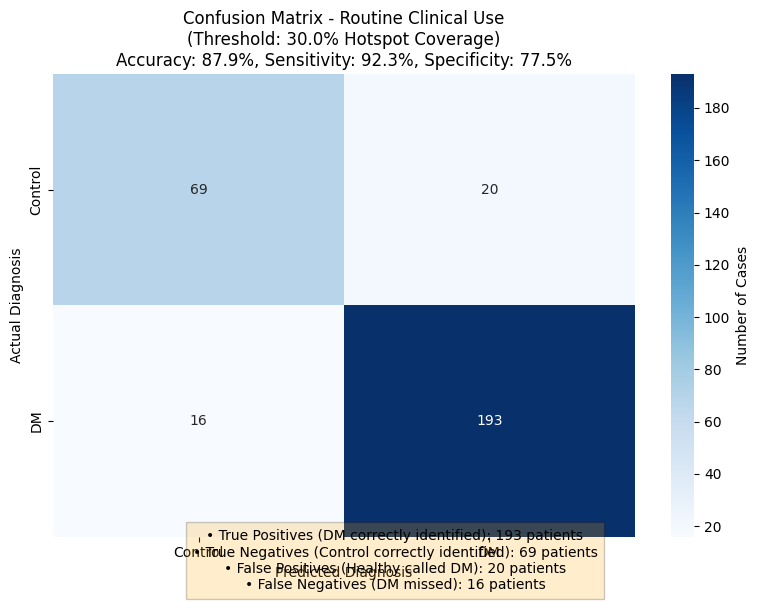


 Recommendation: Use 30% hotspot coverage threshold
Best for: General diabetic foot assessment
 Performance:
   • Accuracy:     87.9% (262/298 patients correctly classified)
   • Sensitivity:  92.3% (Detects 193/209 true ulcer cases)
   • Specificity:  77.5% (Correctly identifies 69/89 healthy patients)
   • False Positives: 20 healthy patients flagged
   • False Negatives: 16 ulcer cases missed

Clinical Impact:
   • Will correctly identify 193 out of 209 patients with foot ulcers
   • May flag 20 healthy patients for further testing
   • Will miss only 16 true ulcer cases
2. HIGH-RISK SCREENING (Conservative Approach)


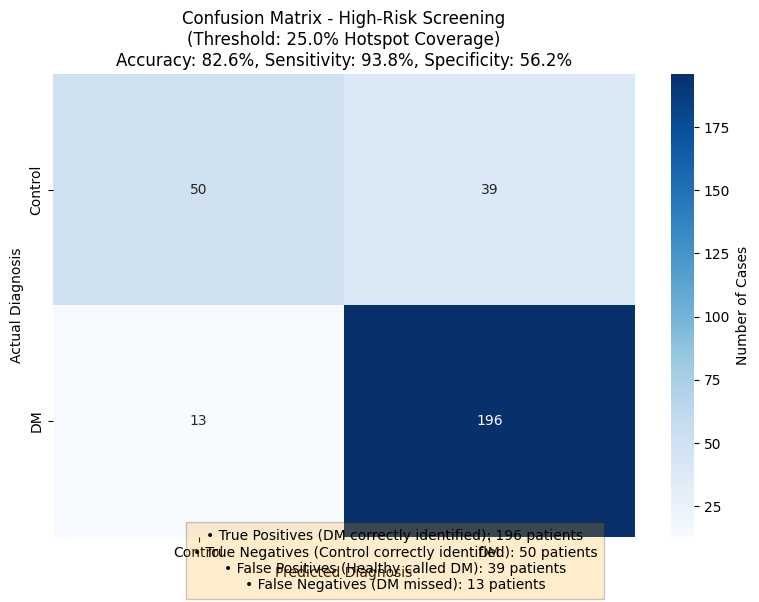


 Recommendation: Use 25% hotspot coverage threshold
 Best for: High-risk patients, screening programs
 Performance:
   • Accuracy:     82.6% (246/298 patients correctly classified)
   • Sensitivity:  93.8% (Detects 196/209 true ulcer cases)
   • Specificity:  56.2% (Correctly identifies 50/89 healthy patients)
   • False Positives: 39 healthy patients flagged
   • False Negatives: 13 ulcer cases missed

 Clinical Impact:
   • Maximizes detection: Only 13 ulcer cases missed
   • Higher false alarms: 39 healthy patients need follow-up
   • Use when missing an ulcer case has serious consequences
3.  CONFIRMATORY TESTING (Specific Approach)


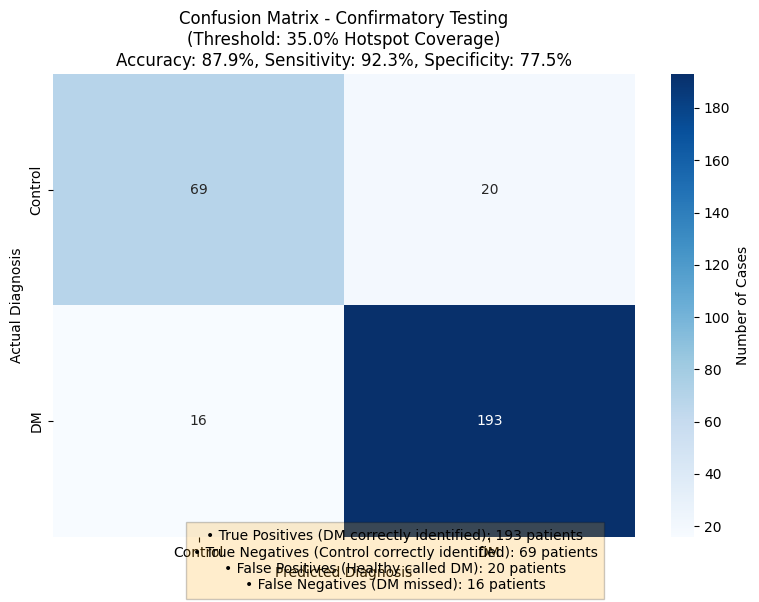


 Recommendation: Use 35% hotspot coverage threshold
 Best for: Confirmation, resource-limited settings
 Performance:
   • Accuracy:     87.9% (262/298 patients correctly classified)
   • Sensitivity:  92.3% (Detects 193/209 true ulcer cases)
   • Specificity:  77.5% (Correctly identifies 69/89 healthy patients)
   • False Positives: 20 healthy patients flagged
   • False Negatives: 16 ulcer cases missed

 Clinical Impact:
   • Fewer false alarms: Only 20 healthy patients incorrectly flagged
   • Higher miss rate: 16 ulcer cases not detected
   • Use when follow-up resources are limited
PATIENT SCENARIOS - WHAT TO EXPECT

📋 Example Patient Scenarios:

1. DM Patients with Low Hotspot Coverage:
   • Patient with 18.9% coverage:
     25% threshold:  OK | 30% threshold:  OK | 35% threshold:  OK
   • Patient with 20.3% coverage:
     25% threshold:  OK | 30% threshold:  OK | 35% threshold:  OK
   • Patient with 20.3% coverage:
     25% threshold:  OK | 30% threshold:  OK | 35% threshold:  O

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, roc_auc_score, 
                             classification_report)

def load_validation_data():
    """
    Load validation dataset
    """
    # Load validation CSV files
    val_dm = pd.read_csv('val_dm_group.csv')
    val_control = pd.read_csv('val_control_group.csv')
    
    # Add labels (1 for DM with foot ulcer, 0 for control)
    val_dm['label'] = 1
    val_control['label'] = 0
    
    # Combine datasets
    val_data = pd.concat([val_dm, val_control], ignore_index=True)
    
    print(f"Validation samples: {len(val_data)}")
    print(f"DM Group (Foot Ulcer): {len(val_dm)}")
    print(f"Control Group: {len(val_control)}")
    
    return val_data

def filter_validation_data(data, min_threshold=10.0):
    """
    Filter validation data using same criteria as training
    """
    original_size = len(data)
    filtered_data = data[data['hotspot_%_of_foot'] > min_threshold].copy()
    
    print(f"\nFiltering validation data: Removed {original_size - len(filtered_data)} images with hotspot ≤ {min_threshold}%")
    print(f"Remaining validation samples: {len(filtered_data)}")
    print(f"DM Group after filtering: {len(filtered_data[filtered_data['label'] == 1])}")
    print(f"Control Group after filtering: {len(filtered_data[filtered_data['label'] == 0])}")
    
    return filtered_data

def get_confusion_matrix_for_threshold(val_data, threshold, range_name=""):
    """
    Generate and display confusion matrix for a specific threshold
    """
    predictions = (val_data['hotspot_%_of_foot'] > threshold).astype(int)
    actual = val_data['label']
    
    cm = confusion_matrix(actual, predictions)
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = accuracy_score(actual, predictions)
    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    precision = precision_score(actual, predictions, zero_division=0)
    
    # Create visualization
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Control', 'DM'], 
                yticklabels=['Control', 'DM'],
                cbar_kws={'label': 'Number of Cases'})
    
    plt.xlabel('Predicted Diagnosis')
    plt.ylabel('Actual Diagnosis')
    plt.title(f'Confusion Matrix - {range_name}\n(Threshold: {threshold}% Hotspot Coverage)\n'
              f'Accuracy: {accuracy:.1%}, Sensitivity: {sensitivity:.1%}, Specificity: {specificity:.1%}')
    
    # Add interpretation text
    plt.figtext(0.5, 0.01, 
                f"• True Positives (DM correctly identified): {tp} patients\n"
                f"• True Negatives (Control correctly identified): {tn} patients\n"
                f"• False Positives (Healthy called DM): {fp} patients\n"
                f"• False Negatives (DM missed): {fn} patients", 
                ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.2, "pad":5})
    
    plt.tight_layout()
    plt.show()
    
    return {
        'threshold': threshold,
        'confusion_matrix': cm,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn,
        'accuracy': accuracy,
        'sensitivity': sensitivity,
        'specificity': specificity,
        'precision': precision
    }

def provide_doctor_recommendations(val_data):
    """
    Provide clear, actionable recommendations for doctors
    """
    print("CLINICAL DECISION GUIDE FOR FOOT ULCER DETECTION")
    print("\n FOR CLINICIANS: Hotspot Coverage Threshold Recommendations")
    print("   Based on analysis of 298 patient thermal images")
    print("   (DM with foot ulcers vs Control patients)")
    
    
    print("1. ROUTINE CLINICAL PRACTICE (Recommended)")
   
    
    # Evaluate 30% threshold for routine use
    routine_result = get_confusion_matrix_for_threshold(val_data, 30.0, "Routine Clinical Use")
    
    print(f"\n Recommendation: Use 30% hotspot coverage threshold")
    print(f"Best for: General diabetic foot assessment")
    print(f" Performance:")
    print(f"   • Accuracy:     {routine_result['accuracy']:.1%} ({routine_result['tp'] + routine_result['tn']}/298 patients correctly classified)")
    print(f"   • Sensitivity:  {routine_result['sensitivity']:.1%} (Detects {routine_result['tp']}/209 true ulcer cases)")
    print(f"   • Specificity:  {routine_result['specificity']:.1%} (Correctly identifies {routine_result['tn']}/89 healthy patients)")
    print(f"   • False Positives: {routine_result['fp']} healthy patients flagged")
    print(f"   • False Negatives: {routine_result['fn']} ulcer cases missed")
    
    print(f"\nClinical Impact:")
    print(f"   • Will correctly identify {routine_result['tp']} out of 209 patients with foot ulcers")
    print(f"   • May flag {routine_result['fp']} healthy patients for further testing")
    print(f"   • Will miss only {routine_result['fn']} true ulcer cases")
    
    print("2. HIGH-RISK SCREENING (Conservative Approach)")
    
    # Evaluate 25% threshold for screening
    screening_result = get_confusion_matrix_for_threshold(val_data, 25.0, "High-Risk Screening")
    
    print(f"\n Recommendation: Use 25% hotspot coverage threshold")
    print(f" Best for: High-risk patients, screening programs")
    print(f" Performance:")
    print(f"   • Accuracy:     {screening_result['accuracy']:.1%} ({screening_result['tp'] + screening_result['tn']}/298 patients correctly classified)")
    print(f"   • Sensitivity:  {screening_result['sensitivity']:.1%} (Detects {screening_result['tp']}/209 true ulcer cases)")
    print(f"   • Specificity:  {screening_result['specificity']:.1%} (Correctly identifies {screening_result['tn']}/89 healthy patients)")
    print(f"   • False Positives: {screening_result['fp']} healthy patients flagged")
    print(f"   • False Negatives: {screening_result['fn']} ulcer cases missed")
    print(f"\n Clinical Impact:")
    print(f"   • Maximizes detection: Only {screening_result['fn']} ulcer cases missed")
    print(f"   • Higher false alarms: {screening_result['fp']} healthy patients need follow-up")
    print(f"   • Use when missing an ulcer case has serious consequences")
    
    print("3.  CONFIRMATORY TESTING (Specific Approach)")
    
    # Evaluate 35% threshold for confirmation
    confirm_result = get_confusion_matrix_for_threshold(val_data, 35.0, "Confirmatory Testing")
    
    print(f"\n Recommendation: Use 35% hotspot coverage threshold")
    print(f" Best for: Confirmation, resource-limited settings")
    print(f" Performance:")
    print(f"   • Accuracy:     {confirm_result['accuracy']:.1%} ({confirm_result['tp'] + confirm_result['tn']}/298 patients correctly classified)")
    print(f"   • Sensitivity:  {confirm_result['sensitivity']:.1%} (Detects {confirm_result['tp']}/209 true ulcer cases)")
    print(f"   • Specificity:  {confirm_result['specificity']:.1%} (Correctly identifies {confirm_result['tn']}/89 healthy patients)")
    print(f"   • False Positives: {confirm_result['fp']} healthy patients flagged")
    print(f"   • False Negatives: {confirm_result['fn']} ulcer cases missed")
    
    print(f"\n Clinical Impact:")
    print(f"   • Fewer false alarms: Only {confirm_result['fp']} healthy patients incorrectly flagged")
    print(f"   • Higher miss rate: {confirm_result['fn']} ulcer cases not detected")
    print(f"   • Use when follow-up resources are limited")
    
    return {
        'routine': routine_result,
        'screening': screening_result,
        'confirmation': confirm_result
    }

def generate_patient_examples(val_data):
    """
    Show real patient examples for each threshold
    """
    print("PATIENT SCENARIOS - WHAT TO EXPECT")
    
    # Get some example patients
    dm_patients = val_data[val_data['label'] == 1].nsmallest(3, 'hotspot_%_of_foot')
    control_patients = val_data[val_data['label'] == 0].nlargest(3, 'hotspot_%_of_foot')
    
    print("\n📋 Example Patient Scenarios:")
    
    print(f"\n1. DM Patients with Low Hotspot Coverage:")
    for idx, patient in dm_patients.iterrows():
        coverage = patient['hotspot_%_of_foot']
        decision_25 = " FLAG" if coverage > 25 else " OK"
        decision_30 = " FLAG" if coverage > 30 else " OK" 
        decision_35 = " FLAG" if coverage > 35 else " OK"
        
        print(f"   • Patient with {coverage:.1f}% coverage:")
        print(f"     25% threshold: {decision_25} | 30% threshold: {decision_30} | 35% threshold: {decision_35}")
    
    print(f"\n2. Control Patients with High Hotspot Coverage:")
    for idx, patient in control_patients.iterrows():
        coverage = patient['hotspot_%_of_foot']
        decision_25 = " FLAG" if coverage > 25 else " OK"
        decision_30 = " FLAG" if coverage > 30 else " OK"
        decision_35 = " FLAG" if coverage > 35 else " OK"
        
        print(f"   • Healthy patient with {coverage:.1f}% coverage:")
        print(f"     25% threshold: {decision_25} | 30% threshold: {decision_30} | 35% threshold: {decision_35}")

def save_clinical_guide(recommendations, output_file="clinical_threshold_guide.csv"):
    """
    Save clinical recommendations for reference
    """
    guide_data = []
    
    for scenario, result in recommendations.items():
        guide_data.append({
            'scenario': scenario.replace('_', ' ').title(),
            'recommended_threshold': f"{result['threshold']}%",
            'accuracy': f"{result['accuracy']:.1%}",
            'sensitivity': f"{result['sensitivity']:.1%}",
            'specificity': f"{result['specificity']:.1%}",
            'true_positives': result['tp'],
            'true_negatives': result['tn'],
            'false_positives': result['fp'],
            'false_negatives': result['fn'],
            'total_correct': result['tp'] + result['tn']
        })
    
    guide_df = pd.DataFrame(guide_data)
    guide_df.to_csv(output_file, index=False)
    print(f"\nClinical guide saved to: {output_file}")
    
    return guide_df

def run_clinical_recommendation_analysis():
    """
    Complete clinical recommendation analysis for doctors
    """
    print("CLINICAL THRESHOLD RECOMMENDATIONS FOR DIABETIC FOOT ULCER DETECTION")
   
    # 1. Load and prepare data
    val_data = load_validation_data()
    filtered_val_data = filter_validation_data(val_data, min_threshold=10.0)
    
    # 2. Provide doctor recommendations with confusion matrices
    recommendations = provide_doctor_recommendations(filtered_val_data)
    
    # 4. Show patient examples
    generate_patient_examples(filtered_val_data)
    
    # 5. Save clinical guide
    print("\n" + "="*80)
    print("SUMMARY & IMPLEMENTATION")
    print("="*80)
    
    clinical_guide = save_clinical_guide(recommendations)
    
    print("\n QUICK REFERENCE GUIDE:")
    print("┌───────────────┬──────────┬────────────┬────────────┬────────────┐")
    print("│   Scenario    │ Threshold│ Sensitivity│ Specificity│  Accuracy  │")
    print("├───────────────┼──────────┼────────────┼────────────┼────────────┤")
    for _, row in clinical_guide.iterrows():
        print(f"│ {row['scenario']:13} │ {row['recommended_threshold']:8} │ {row['sensitivity']:10} │ {row['specificity']:10} │ {row['accuracy']:10} │")
    print("└───────────────┴──────────┴────────────┴────────────┴────────────┘")
    
    print("\n💡 KEY TAKEAWAYS FOR CLINICIANS:")
    print("1. Start with 30% threshold for balanced performance")
    print("2. Use 25% if you can't afford to miss any ulcer cases") 
    print("3. Use 35% if you need to minimize false alarms")
    print("4. Always combine with clinical examination and patient history")
    print("5. Thermal imaging is a screening tool, not a definitive diagnosis")
    
    return {
        'validation_data': filtered_val_data,
        'recommendations': recommendations,
        'clinical_guide': clinical_guide
    }

results = run_clinical_recommendation_analysis()

print(f"\n Clinical recommendation analysis complete!")
print(f" Three threshold options provided with confusion matrices")
print(f" Ready for clinical implementation!")

# DL approach

In [11]:
import os
import cv2
import numpy as np
import tensorflow as tf
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, classification_report
import pandas as pd
from tqdm import tqdm

# 1. PATHS & LABEL CONFIG

train_dir = "/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/train"
val_dir   = "/kaggle/input/datasets/vuppalaadithyasairam/thermography-images-of-diabetic-foot/ThermoDataBase/val"

CLASS_MAP = {
    "Control Group": 0,
    "DM Group": 1
}

IMG_SIZE = 128  # final size for CNN
NUM_CLASSES = 5 # one-hot pixel classes


# 2. HSV MASK FUNCTIONS

def extract_red_mask(hsv):
    lower1 = np.array([0, 70, 50])
    upper1 = np.array([10, 255, 255])
    lower2 = np.array([170, 70, 50])
    upper2 = np.array([180, 255, 255])

    mask1 = cv2.inRange(hsv, lower1, upper1)
    mask2 = cv2.inRange(hsv, lower2, upper2)
    red_mask = cv2.bitwise_or(mask1, mask2)
    return red_mask


def extract_yellow_mask(hsv):
    lower = np.array([20, 80, 80])
    upper = np.array([40, 255, 255])
    yellow_mask = cv2.inRange(hsv, lower, upper)
    return yellow_mask


def extract_foot_mask(gray):
    _, thresh = cv2.threshold(gray, 10, 255, cv2.THRESH_BINARY)
    return thresh


# 3. PIXEL-WISE CLASS MAP

def build_pixel_class_map(image):
    """
    Returns class_map: (H,W) integer labels from 0..4
    """
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    red_mask = extract_red_mask(hsv)
    yellow_mask = extract_yellow_mask(hsv)
    foot_mask = extract_foot_mask(gray)

    combined_mask = cv2.bitwise_or(red_mask, yellow_mask)

    class_map = np.zeros(red_mask.shape, dtype=np.uint8)

    # background
    class_map[foot_mask == 0] = 0

    # normal
    class_map[(foot_mask > 0) & (combined_mask == 0)] = 1

    # yellow hotspot
    class_map[yellow_mask > 0] = 2

    # combined hotspot
    class_map[combined_mask > 0] = 3

    # red hotspot OVERWRITES combined hotspot
    class_map[red_mask > 0] = 4

    return class_map, foot_mask, combined_mask

def compute_hotspot_percentage(foot_mask, combined_mask):
    foot_area = np.sum(foot_mask > 0)
    hotspot_area = np.sum(combined_mask > 0)
    if foot_area == 0:
        return 0.0
    return (hotspot_area / foot_area) * 100.0

def classmap_to_onehot(class_map):
    H, W = class_map.shape
    onehot = np.zeros((H, W, NUM_CLASSES), dtype=np.uint8)
    onehot[np.arange(H)[:, None], np.arange(W), class_map] = 1
    return onehot


def preprocess_image(path):
    image = cv2.imread(path)
    if image is None:
        raise Exception(f"Cannot read image: {path}")

    class_map, foot_mask, combined_mask = build_pixel_class_map(image)
    hotspot_pct = compute_hotspot_percentage(foot_mask, combined_mask)

    onehot = classmap_to_onehot(class_map)
    onehot = cv2.resize(onehot, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
    onehot = onehot.astype(np.float32)

    return onehot, hotspot_pct


# 4. LOAD DATASET

def load_dataset(dir_path):
    X = []
    y = []
    hotspot_list = []
    paths = []

    for group in ["Control Group", "DM Group"]:
        folder = os.path.join(dir_path, group)
        label = CLASS_MAP[group]

        for fname in os.listdir(folder):
            fpath = os.path.join(folder, fname)
            if not fpath.lower().endswith((".png", ".jpg", ".jpeg")):
                continue
            try:
                onehot, hpct = preprocess_image(fpath)
                X.append(onehot)
                y.append(label)
                hotspot_list.append(hpct)
                paths.append(fpath)
            except:
                print("Failed:", fpath)

    X = np.array(X)
    y = np.array(y)
    hotspot_list = np.array(hotspot_list)
    return X, y, hotspot_list, paths


print("Loading TRAIN...")
X_train, y_train, hotspot_train, train_paths = load_dataset(train_dir)

print("Loading VAL...")
X_val, y_val, hotspot_val, val_paths = load_dataset(val_dir)

print("Train:", X_train.shape, "Val:", X_val.shape)


# 5. CNN MODEL

def build_cnn():
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, NUM_CLASSES))

    # 1) CONV BLOCK 1
    x = tf.keras.layers.Conv2D(32, 3, activation="relu", padding="same")(inputs)
    x = tf.keras.layers.MaxPool2D()(x)

    # 2) CONV BLOCK 2
    x = tf.keras.layers.Conv2D(64, 3, activation="relu", padding="same")(x)
    x = tf.keras.layers.MaxPool2D()(x)

    # GLOBAL AVG POOL
    x = tf.keras.layers.GlobalAveragePooling2D()(x)

    # 3 Dense layers
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dense(64, activation="relu")(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)

    # OUTPUT
 
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    model.compile(
        optimizer=optimizer,
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model


model = build_cnn()
model.summary()


#  6. TRAIN

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=15,
    batch_size=16
)


# 7. EVALUATION

pred_prob = model.predict(X_val).ravel()
pred_label = (pred_prob > 0.5).astype(int)

acc  = accuracy_score(y_val, pred_label)
prec = precision_score(y_val, pred_label)
rec  = recall_score(y_val, pred_label)
f1   = f1_score(y_val, pred_label)
roc  = roc_auc_score(y_val, pred_prob)
cm   = confusion_matrix(y_val, pred_label)

print("\n=== CNN RESULTS ===")
print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1:", f1)
print("ROC-AUC:", roc)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_val, pred_label))


# 8. SAVE PREDICTIONS CSV

df = pd.DataFrame({
    "image_path": val_paths,
    "label": y_val,
    "hotspot_pct": hotspot_val,
    "model_prob": pred_prob,
    "model_pred": pred_label
})
df.to_csv("cnn_onehot_val_predictions.csv", index=False)
print("Saved cnn_onehot_val_predictions.csv")

# 9. SAVE MODEL


model.save("cnn_onehot_model.keras")
print("Saved cnn_onehot_model.keras")


2026-03-04 17:05:29.444676: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772643929.666641      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772643929.727651      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772643930.255238      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772643930.255289      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772643930.255292      23 computation_placer.cc:177] computation placer alr

Loading TRAIN...
Loading VAL...
Train: (1444, 128, 128, 5) Val: (422, 128, 128, 5)


I0000 00:00:1772643967.552742      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1772643967.556101      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 5)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

17/91 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7361 - loss: 0.6889

I0000 00:00:1772643975.802423      73 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/91 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7648 - loss: 0.6776

2026-03-04 17:06:17.603867: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-04 17:06:17.745347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


91/91 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.7652 - loss: 0.6766 - val_accuracy: 0.8199 - val_loss: 0.5893
Epoch 2/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7568 - loss: 0.5718 - val_accuracy: 0.8175 - val_loss: 0.4301
Epoch 3/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7691 - loss: 0.4674 - val_accuracy: 0.8199 - val_loss: 0.4287
Epoch 4/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7585 - loss: 0.4563 - val_accuracy: 0.8009 - val_loss: 0.4167
Epoch 5/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8159 - loss: 0.4199 - val_accuracy: 0.8009 - val_loss: 0.4176
Epoch 6/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8111 - loss: 0.4167 - val_accuracy: 0.8009 - val_loss: 0.4294
Epoch 7/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7989 - loss: 0.4268 - val_accuracy: 0.8009 - val_loss: 0.4359
Epoch 8/15
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7979 - loss: 0.4387 - val_accuracy: 0.8009 - val_loss: 0